In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from collections import defaultdict, Counter
import re
from pathlib import Path


BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "cluster_characterization")
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Entorno configurado")
print(f"  BASE_DIR: {BASE_DIR}")
print(f"  DATA_DIR: {DATA_DIR}")
print(f"  PLOTS_DIR: {PLOTS_DIR}")

Entorno configurado
  BASE_DIR: /home/aninotna/magister/tesis/justh2_pipeline
  DATA_DIR: /home/aninotna/magister/tesis/justh2_pipeline/data
  PLOTS_DIR: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization


## Importación de Resultados de Clustering

Cargamos los resultados exportados desde el notebook `07_experiments_1_clustering.ipynb`.

In [2]:
import pickle
from glob import glob

DATA_DIR = "/home/aninotna/magister/tesis/justh2_pipeline/data"

# ACTUALIZADO: Buscar en autoencoder_trained_v2 (nuevo formato de exportación)
EXPORT_DIR = os.path.join(DATA_DIR, "autoencoder_trained_v2")

# Buscar archivos del nuevo formato
clustering_files = sorted(glob(os.path.join(EXPORT_DIR, "experiment1_clustering_*.pkl")))

if not clustering_files:
    # Fallback al formato antiguo
    print("No se encontraron archivos en formato nuevo, buscando formato antiguo...")
    CLUSTERING_DIR = os.path.join(DATA_DIR, "autoencoder_results", "clustering")
    clustering_files = sorted(glob(os.path.join(CLUSTERING_DIR, "clustering_results_*.pkl")))
    
    if not clustering_files:
        raise FileNotFoundError(f"No se encontraron archivos de clustering en ninguno de los directorios")
    
    # Cargar formato antiguo
    latest_file = clustering_files[-1]
    print(f"Cargando formato antiguo: {os.path.basename(latest_file)}")
    
    with open(latest_file, "rb") as f:
        clustering_data = pickle.load(f)
    
    # Extraer datos del formato antiguo
    K_CLUSTERS = clustering_data["K_CLUSTERS"]
    SEED = clustering_data["SEED"]
    N_PER_SCENARIO = clustering_data["N_PER_SCENARIO"]
    MODEL_ORDER = clustering_data["MODEL_ORDER"]
    feature_names = clustering_data["feature_names"]
    
    lat = clustering_data["coords"]["lat"]
    lon = clustering_data["coords"]["lon"]
    extent = clustering_data["coords"]["extent"]
    
    CLUSTERING_RESULTS = clustering_data["CLUSTERING_RESULTS"]
    LATENTS = clustering_data["LATENTS"]
    
    X_BASE = clustering_data["data_blocks"]["X_BASE"]
    X245_orig = clustering_data["data_blocks"]["X245_orig"]
    X370_orig = clustering_data["data_blocks"]["X370_orig"]
    X585_orig = clustering_data["data_blocks"]["X585_orig"]
    
    models_path = None
    model_dims = None
    
else:
    # Cargar formato nuevo (completo)
    latest_file = clustering_files[-1]
    print(f"Cargando formato nuevo: {os.path.basename(latest_file)}")
    
    with open(latest_file, "rb") as f:
        data = pickle.load(f)
    
    # Extraer objetos del nuevo formato
    models_path = data["models_path"]
    model_dims = data["model_dims"]
    LATENTS = data["LATENTS"]
    CLUSTERING_RESULTS = data["CLUSTERING_RESULTS"]
    K_CLUSTERS = data["K_CLUSTERS"]
    MODEL_ORDER = data["MODEL_ORDER"]
    feature_names = data["feature_names"]
    X_BASE = data["X_BASE"]
    X245_orig = data["X245_orig"]
    X370_orig = data["X370_orig"]
    X585_orig = data["X585_orig"]
    lat = data["lat"]
    lon = data["lon"]
    extent = data["extent"]
    
    # CRÍTICO: Cargar coords_df con coordenadas exactas de píxeles válidos
    coords_df = data.get("coords_df", None)
    if coords_df is None:
        print("⚠ coords_df no encontrado en export, se requiere re-exportar desde notebook 1")
    
    # Índices de variables (si están disponibles)
    var_indices = data.get("variable_indices", {})
    
    # Calcular N_PER_SCENARIO (número de píxeles) desde X_BASE
    N_PER_SCENARIO = X_BASE.shape[0]

print(f"\nDatos cargados exitosamente:")
print(f"  Archivo: {os.path.basename(latest_file)}")
print(f"  K_CLUSTERS: {K_CLUSTERS}")
print(f"  Modelos: {MODEL_ORDER}")
print(f"  Píxeles BASE: {X_BASE.shape[0]}")
print(f"  Features climáticas: {len(feature_names)}")
print(f"  Coordenadas: lat={len(lat)}, lon={len(lon)}")

if models_path:
    print(f"\nModelos PyTorch disponibles:")
    for model_key, path in models_path.items():
        dims = model_dims[model_key]
        print(f"  {model_key}: {os.path.basename(path)} (input={dims['input_dim']}, latent={dims['latent_dim']})")

print(f"\nResultados de clustering:")
for model_key in MODEL_ORDER:
    results = CLUSTERING_RESULTS[model_key]
    print(f"  {model_key}:")
    print(f"    Labels BASE: {results['labels_base'].shape}")
    print(f"    Labels T245: {results['labels_T245'].shape}")
    print(f"    Labels T370: {results['labels_T370'].shape}")
    print(f"    Labels T585: {results['labels_T585'].shape}")
    print(f"    Centroides: {results['centroids'].shape}")
    print(f"    Inertia: {results['inertia']:.2f}")


Cargando formato nuevo: experiment1_clustering_20251115_204010.pkl

Datos cargados exitosamente:
  Archivo: experiment1_clustering_20251115_204010.pkl
  K_CLUSTERS: 10
  Modelos: ['AE', 'VAE']
  Píxeles BASE: 1983
  Features climáticas: 47
  Coordenadas: lat=24, lon=42

Modelos PyTorch disponibles:
  AE: AE_model_20251115_204010.pt (input=29, latent=8)
  VAE: VAE_model_20251115_204010.pt (input=29, latent=8)

Resultados de clustering:
  AE:
    Labels BASE: (1983,)
    Labels T245: (661,)
    Labels T370: (661,)
    Labels T585: (661,)
    Centroides: (10, 8)
    Inertia: 5664.12
  VAE:
    Labels BASE: (1983,)
    Labels T245: (661,)
    Labels T370: (661,)
    Labels T585: (661,)
    Centroides: (10, 8)
    Inertia: 1941.74


In [3]:
import pickle
from sklearn.preprocessing import StandardScaler

def fit_base_scaler(Z_base):
    """
    Ajusta un StandardScaler con el espacio latente BASE.
    
    Parámetros
    ----------
    Z_base : np.ndarray
        Espacio latente de BASE (N_base, latent_dim)
    
    Retorna
    -------
    scaler : StandardScaler
        Escalador ajustado con BASE
    """
    scaler = StandardScaler()
    scaler.fit(Z_base)
    
    print(f"Escalador ajustado con BASE")
    print(f"  Shape: {Z_base.shape}")
    print(f"  Media ajustada: {scaler.mean_[:5]}")
    print(f"  Std ajustada: {scaler.scale_[:5]}")
    
    return scaler


def transform_latents_with_base_scaler(Z_base, Z_T245, Z_T370, Z_T585, scaler=None):
    """
    Escala todos los espacios latentes usando el escalador de BASE.
    
    Parámetros
    ----------
    Z_base : np.ndarray
        Espacio latente BASE (N_base, latent_dim)
    Z_T245 : np.ndarray
        Espacio latente SSP245 (N_245, latent_dim)
    Z_T370 : np.ndarray
        Espacio latente SSP370 (N_370, latent_dim)
    Z_T585 : np.ndarray
        Espacio latente SSP585 (N_585, latent_dim)
    scaler : StandardScaler, opcional
        Si se proporciona, usa este escalador. Si no, ajusta uno nuevo con BASE.
    
    Retorna
    -------
    dict
        Diccionario con:
        - 'Z_base_sc': BASE escalado
        - 'Z_T245_sc': SSP245 escalado
        - 'Z_T370_sc': SSP370 escalado
        - 'Z_T585_sc': SSP585 escalado
        - 'scaler': el escalador usado
        - 'verification': verificación de media/std en BASE escalado
    """
    
    # Ajustar escalador con BASE si no se proporciona
    if scaler is None:
        scaler = fit_base_scaler(Z_base)
    
    # Transformar todos los espacios latentes
    Z_base_sc = scaler.transform(Z_base)
    Z_T245_sc = scaler.transform(Z_T245)
    Z_T370_sc = scaler.transform(Z_T370)
    Z_T585_sc = scaler.transform(Z_T585)
    
    # Verificación: media ≈ 0 y std ≈ 1 solo en BASE
    base_mean = Z_base_sc.mean(axis=0)
    base_std = Z_base_sc.std(axis=0)
    
    verification = {
        'base_mean_close_to_zero': np.allclose(base_mean, 0, atol=1e-10),
        'base_std_close_to_one': np.allclose(base_std, 1, atol=1e-10),
        'base_mean': base_mean,
        'base_std': base_std,
        'T245_mean': Z_T245_sc.mean(axis=0),
        'T245_std': Z_T245_sc.std(axis=0),
        'T370_mean': Z_T370_sc.mean(axis=0),
        'T370_std': Z_T370_sc.std(axis=0),
        'T585_mean': Z_T585_sc.mean(axis=0),
        'T585_std': Z_T585_sc.std(axis=0),
    }
    
    print("\nTransformación completada:")
    print(f"  BASE:   {Z_base.shape} → {Z_base_sc.shape}")
    print(f"  SSP245: {Z_T245.shape} → {Z_T245_sc.shape}")
    print(f"  SSP370: {Z_T370.shape} → {Z_T370_sc.shape}")
    print(f"  SSP585: {Z_T585.shape} → {Z_T585_sc.shape}")
    
    print(f"\nVerificación BASE escalado:")
    print(f"  Media ≈ 0: {verification['base_mean_close_to_zero']} (max abs = {np.abs(base_mean).max():.2e})")
    print(f"  Std ≈ 1:   {verification['base_std_close_to_one']} (max diff = {np.abs(base_std - 1).max():.2e})")
    
    print(f"\nEstadísticas escenarios futuros (NO deben ser 0/1):")
    print(f"  SSP245 - Media: {verification['T245_mean'][:5]}")
    print(f"  SSP245 - Std:   {verification['T245_std'][:5]}")
    print(f"  SSP370 - Media: {verification['T370_mean'][:5]}")
    print(f"  SSP370 - Std:   {verification['T370_std'][:5]}")
    print(f"  SSP585 - Media: {verification['T585_mean'][:5]}")
    print(f"  SSP585 - Std:   {verification['T585_std'][:5]}")
    
    return {
        'Z_base_sc': Z_base_sc,
        'Z_T245_sc': Z_T245_sc,
        'Z_T370_sc': Z_T370_sc,
        'Z_T585_sc': Z_T585_sc,
        'scaler': scaler,
        'verification': verification
    }


def save_base_scaler(scaler, filepath):
    """
    Guarda el escalador BASE para uso futuro.
    
    Parámetros
    ----------
    scaler : StandardScaler
        Escalador ajustado con BASE
    filepath : str
        Ruta donde guardar el escalador
    """
    with open(filepath, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Escalador guardado en: {filepath}")


def load_base_scaler(filepath):
    """
    Carga un escalador BASE previamente guardado.
    
    Parámetros
    ----------
    filepath : str
        Ruta del escalador guardado
    
    Retorna
    -------
    scaler : StandardScaler
        Escalador cargado
    """
    with open(filepath, 'rb') as f:
        scaler = pickle.load(f)
    print(f"Escalador cargado desde: {filepath}")
    print(f"  Media: {scaler.mean_[:5]}")
    print(f"  Std: {scaler.scale_[:5]}")
    return scaler


print("Utilidades de escalado consistente cargadas")
print("\nFunciones disponibles:")
print("  - fit_base_scaler(Z_base)")
print("  - transform_latents_with_base_scaler(Z_base, Z_T245, Z_T370, Z_T585, scaler=None)")
print("  - save_base_scaler(scaler, filepath)")
print("  - load_base_scaler(filepath)")

Utilidades de escalado consistente cargadas

Funciones disponibles:
  - fit_base_scaler(Z_base)
  - transform_latents_with_base_scaler(Z_base, Z_T245, Z_T370, Z_T585, scaler=None)
  - save_base_scaler(scaler, filepath)
  - load_base_scaler(filepath)


In [4]:
# Cargar espacios latentes existentes (ejemplo con AE)
Z_base = LATENTS["AE"]["base"]
Z_T245 = LATENTS["AE"]["T245"]
Z_T370 = LATENTS["AE"]["T370"]
Z_T585 = LATENTS["AE"]["T585"]

print("Espacios latentes cargados:")
print(f"  BASE:   {Z_base.shape}")
print(f"  SSP245: {Z_T245.shape}")
print(f"  SSP370: {Z_T370.shape}")
print(f"  SSP585: {Z_T585.shape}")

# Aplicar escalado consistente
scaled_results = transform_latents_with_base_scaler(
    Z_base=Z_base,
    Z_T245=Z_T245,
    Z_T370=Z_T370,
    Z_T585=Z_T585
)

# Extraer resultados
Z_base_sc = scaled_results['Z_base_sc']
Z_T245_sc = scaled_results['Z_T245_sc']
Z_T370_sc = scaled_results['Z_T370_sc']
Z_T585_sc = scaled_results['Z_T585_sc']
base_scaler = scaled_results['scaler']

# Guardar escalador para uso futuro
scaler_path = os.path.join(EXPORT_DIR, "base_scaler_AE.pkl")
save_base_scaler(base_scaler, scaler_path)

print("\nEspacios latentes escalados disponibles:")
print("  - Z_base_sc")
print("  - Z_T245_sc")
print("  - Z_T370_sc")
print("  - Z_T585_sc")
print("  - base_scaler")

Espacios latentes cargados:
  BASE:   (1983, 8)
  SSP245: (661, 8)
  SSP370: (661, 8)
  SSP585: (661, 8)
Escalador ajustado con BASE
  Shape: (1983, 8)
  Media ajustada: [-0.70330967  0.42800138  0.26757134  0.07490441  0.19109943]
  Std ajustada: [1.3451052  1.5630926  1.40206054 1.39762206 1.39828872]

Transformación completada:
  BASE:   (1983, 8) → (1983, 8)
  SSP245: (661, 8) → (661, 8)
  SSP370: (661, 8) → (661, 8)
  SSP585: (661, 8) → (661, 8)

Verificación BASE escalado:
  Media ≈ 0: False (max abs = 2.95e-07)
  Std ≈ 1:   True (max diff = 5.96e-07)

Estadísticas escenarios futuros (NO deben ser 0/1):
  SSP245 - Media: [-0.35328916 -0.21621472  0.8085322  -0.4295076  -1.3477892 ]
  SSP245 - Std:   [0.54613835 1.5512967  1.1425194  0.7996502  0.9367821 ]
  SSP370 - Media: [ 1.0290517  -0.63318604 -0.7750661  -0.03493163  0.4093097 ]
  SSP370 - Std:   [0.34723166 0.5851538  1.4075351  0.6677895  0.87963384]
  SSP585 - Media: [-1.0649142   0.8810821   0.18346253  0.9135463   1.418

In [5]:
# 1) Exponer labels por escenario (si ya vienen en el PKL)
LABELS = {}
for model_key in MODEL_ORDER:
    res = CLUSTERING_RESULTS[model_key]
    LABELS[model_key] = {
        "base":  res.get("labels_base",  None),
        "T245":  res.get("labels_T245",  None),
        "T370":  res.get("labels_T370",  None),
        "T585":  res.get("labels_T585",  None),
    }

# 2) Fallback: si falta algún labels_T***, lo calculamos por nearest-centroid
def assign_by_nearest_centroid(Z_sc, centroids):
    # dist^2 = ||x||^2 + ||c||^2 - 2 x·c
    x2 = np.sum(Z_sc**2, axis=1, keepdims=True)
    c2 = np.sum(centroids**2, axis=1, keepdims=True).T
    d2 = x2 + c2 - 2 * (Z_sc @ centroids.T)
    return np.argmin(d2, axis=1).astype(int)

for model_key in MODEL_ORDER:
    cents = CLUSTERING_RESULTS[model_key]["centroids"]       # (K, latent_dim)

    # Necesitas los latentes ESCALADOS con el scaler de BASE (ya los generaste como Z_*_sc)
    # Si aún no los tienes en este punto, muévelos antes o vuelve a escalarlos aquí.
    missing = []
    for tag, Z_sc in [("T245", Z_T245_sc), ("T370", Z_T370_sc), ("T585", Z_T585_sc)]:
        if LABELS[model_key][tag] is None:
            LABELS[model_key][tag] = assign_by_nearest_centroid(Z_sc, cents)
            missing.append(tag)

    # Asegurar BASE también
    if LABELS[model_key]["base"] is None:
        LABELS[model_key]["base"] = assign_by_nearest_centroid(Z_base_sc, cents)
        missing.insert(0, "base")

    if missing:
        print(f"[{model_key}] Etiquetas generadas por nearest-centroid para: {', '.join(missing)}")

# 3) Chequeo rápido de integridad
for model_key in MODEL_ORDER:
    lb = LABELS[model_key]["base"]
    lt245 = LABELS[model_key]["T245"]
    lt370 = LABELS[model_key]["T370"]
    lt585 = LABELS[model_key]["T585"]
    print(f"\n[{model_key}] labels: base={lb.shape}, T245={lt245.shape}, T370={lt370.shape}, T585={lt585.shape}")



[AE] labels: base=(1983,), T245=(661,), T370=(661,), T585=(661,)

[VAE] labels: base=(1983,), T245=(661,), T370=(661,), T585=(661,)


In [6]:
# CORRECCIÓN: X_BASE NO usa las primeras 29 posiciones secuenciales de feature_names
# Usa índices específicos: base_mean_idx + non_idx
base_mean_idx = [11, 14, 17, 20, 23, 26, 29, 32, 35]  # Década 2020
non_idx = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 38, 39, 40, 41, 42, 43, 44, 45, 46]  # Estáticas + std_T
xbase_indices = base_mean_idx + non_idx

# Crear lista ordenada de nombres que corresponden a las columnas de X_BASE
xbase_feature_names = [feature_names[i] for i in xbase_indices]

available_in_xbase = set(xbase_feature_names)
all_features = set(feature_names)
not_in_xbase = all_features - available_in_xbase

print(f"Variables EN X_BASE (usables para etiquetado): {len(available_in_xbase)}")
print(f"Variables NO en X_BASE (no usables): {len(not_in_xbase)}\n")

print("Variables NO disponibles en X_BASE:")
for i, var in enumerate(sorted(not_in_xbase), 1):
    print(f"  {i:2d}. {var}")

# Verificar disponibilidad de variables clave
std_t_in_xbase = [v for v in available_in_xbase if 'std_T' in v]
cdd_in_xbase = [v for v in available_in_xbase if 'cdd' in v]
rx5_in_xbase = [v for v in available_in_xbase if 'rx5day' in v]
sdii_in_xbase = [v for v in available_in_xbase if 'sdii' in v]

print("\n\nRESUMEN CORRECTO:")
print(f"  - Variables std_T (variabilidad temporal): {len(std_t_in_xbase)} de 9 SÍ disponibles ✓")
print(f"  - CDD (sequías) década 2020: {'SÍ' if cdd_in_xbase else 'NO'} disponible")
print(f"  - RX5DAY (lluvia 5 días) década 2020: {'SÍ' if rx5_in_xbase else 'NO'} disponible")
print(f"  - SDII (intensidad diaria) década 2020: {'SÍ' if sdii_in_xbase else 'NO'} disponible")
print(f"\n  Variables std_T disponibles: {len(std_t_in_xbase)}")
for v in sorted(std_t_in_xbase):
    print(f"    • {v}")
print(f"\n  FALTANTES: Solo décadas 2050 y 2080 de CDD, RX5DAY, SDII (porque X_BASE usa solo 2020)")

Variables EN X_BASE (usables para etiquetado): 29
Variables NO en X_BASE (no usables): 18

Variables NO disponibles en X_BASE:
   1. calliope_h2_prod_ton_decadal_mean_2050
   2. calliope_h2_prod_ton_decadal_mean_2080
   3. climate_cdd_decadal_mean_2050
   4. climate_cdd_decadal_mean_2080
   5. climate_prcptot_decadal_mean_2050
   6. climate_prcptot_decadal_mean_2080
   7. climate_r10mm_decadal_mean_2050
   8. climate_r10mm_decadal_mean_2080
   9. climate_rx1day_decadal_mean_2050
  10. climate_rx1day_decadal_mean_2080
  11. climate_rx5day_decadal_mean_2050
  12. climate_rx5day_decadal_mean_2080
  13. climate_sdii_decadal_mean_2050
  14. climate_sdii_decadal_mean_2080
  15. climate_tmax_mean_decadal_mean_2050
  16. climate_tmax_mean_decadal_mean_2080
  17. climate_tmin_mean_decadal_mean_2050
  18. climate_tmin_mean_decadal_mean_2080


RESUMEN CORRECTO:
  - Variables std_T (variabilidad temporal): 9 de 9 SÍ disponibles ✓
  - CDD (sequías) década 2020: SÍ disponible
  - RX5DAY (lluvia 5 dí

## Análisis de Variables por Cluster

Calculamos el perfil climático medio de cada cluster y la importancia de cada variable para caracterizarlos.

In [7]:
def compute_cluster_profiles(X_data, labels, K, feature_names):
    """
    Calcula perfiles climáticos por cluster.
    
    Retorna:
    - profiles_mean: Media de cada variable por cluster
    - profiles_std: Desviación estándar por cluster
    - global_mean: Media global de cada variable
    - global_std: Desviación estándar global
    """
    n_features = X_data.shape[1]
    profiles_mean = np.zeros((K, n_features))
    profiles_std = np.zeros((K, n_features))
    
    for k in range(K):
        mask = (labels == k)
        if mask.sum() > 0:
            profiles_mean[k] = X_data[mask].mean(axis=0)
            profiles_std[k] = X_data[mask].std(axis=0)
    
    global_mean = X_data.mean(axis=0)
    global_std = X_data.std(axis=0)
    
    return profiles_mean, profiles_std, global_mean, global_std


def compute_variable_importance(profiles_mean, global_mean, global_std):
    """
    Calcula la importancia de cada variable para cada cluster.
    
    Importancia = (media_cluster - media_global) / std_global
    
    Valores positivos: la variable está elevada en ese cluster
    Valores negativos: la variable está reducida en ese cluster
    """
    K, n_features = profiles_mean.shape
    importance = np.zeros((K, n_features))
    
    for k in range(K):
        importance[k] = (profiles_mean[k] - global_mean) / (global_std + 1e-8)
    
    return importance


print("Funciones de análisis definidas")

Funciones de análisis definidas


In [8]:
cluster_profiles = {}

for model_key in MODEL_ORDER:
    results = CLUSTERING_RESULTS[model_key]
    labels_base = results['labels_base']
    
    profiles_mean, profiles_std, global_mean, global_std = compute_cluster_profiles(
        X_BASE, labels_base, K_CLUSTERS, feature_names
    )
    
    importance = compute_variable_importance(profiles_mean, global_mean, global_std)
    
    cluster_profiles[model_key] = {
        'profiles_mean': profiles_mean,
        'profiles_std': profiles_std,
        'global_mean': global_mean,
        'global_std': global_std,
        'importance': importance
    }
    
    print(f"\n{model_key}:")
    print(f"  Perfiles calculados: {profiles_mean.shape}")
    print(f"  Importancia calculada: {importance.shape}")

print("\nPerfiles climáticos calculados para todos los modelos")


AE:
  Perfiles calculados: (10, 29)
  Importancia calculada: (10, 29)

VAE:
  Perfiles calculados: (10, 29)
  Importancia calculada: (10, 29)

Perfiles climáticos calculados para todos los modelos


### Variables más Importantes por Cluster

Identificamos las variables con mayor desviación respecto a la media global (en términos de desviaciones estándar).

In [9]:
def get_top_variables_per_cluster(importance: np.ndarray,
                                  xbase_feature_names: list[str],
                                  top_n: int = 5,
                                  include_mask: np.ndarray | None = None):
    """
    Retorna top variables por clúster ordenadas por |importancia| con dirección (↑/↓).
    - importance: (K, n_features) con importancias firmadas (p.ej., z-score medio del clúster).
    - xbase_feature_names: nombres (n_features) correspondientes a 'importance'.
    - include_mask: bool mask (n_features,) para incluir/excluir variables (opcional).
    """
    # Validaciones
    K, n_features = importance.shape
    assert len(xbase_feature_names) == n_features, \
        f"len(names)={len(xbase_feature_names)} != n_features={n_features}"
    # => Normaliza top_n
    top_n = int(min(max(top_n, 1), n_features))
    # => Manejo de NaN
    imp = np.nan_to_num(importance, nan=0.0, posinf=0.0, neginf=0.0)

    # => Máscara opcional de inclusión
    if include_mask is not None:
        assert include_mask.shape[0] == n_features, "include_mask len mismatch"
        keep_idx = np.where(include_mask.astype(bool))[0]
    else:
        keep_idx = np.arange(n_features)

    top_vars = {}
    for k in range(K):
        # => Trabaja sobre índices permitidos
        vals = imp[k, keep_idx]
        abs_vals = np.abs(vals)

        # => Orden estable: primero |imp| desc, luego imp desc (prefiere positivos si empatan)
        order = np.lexsort((-vals, -abs_vals))  # lexsort usa clave secundaria primero
        sel = keep_idx[order[:top_n]]

        items = []
        for idx in sel:
            vname = xbase_feature_names[idx]
            vimp = float(imp[k, idx])
            direction = "↑" if vimp > 0 else "↓" if vimp < 0 else "·"
            items.append({
                "variable": vname,
                "importance": vimp,
                "direction": direction,
                "abs_importance": abs(vimp),
                "feature_idx": int(idx)
            })
        top_vars[k] = items

    return top_vars


for model_key in MODEL_ORDER:
    importance = cluster_profiles[model_key]['importance']
    top_vars = get_top_variables_per_cluster(importance, xbase_feature_names, top_n=8)  # CORREGIDO
    
    print(f"\n{'='*80}")
    print(f"MODELO: {model_key}")
    print(f"{'='*80}")
    
    for k in range(K_CLUSTERS):
        labels_base = CLUSTERING_RESULTS[model_key]['labels_base']
        n_pixels = (labels_base == k).sum()
        
        print(f"\nCluster {k} (n={n_pixels} píxeles)")
        print(f"{'-'*80}")
        
        for i, var_info in enumerate(top_vars[k], 1):
            print(f"  {i}. {var_info['direction']} {var_info['variable']:30s} "
                  f"imp={var_info['importance']:+.3f} std "
                  f"(|imp|={var_info['abs_importance']:.3f})")
    
    cluster_profiles[model_key]['top_variables'] = top_vars


MODELO: AE

Cluster 0 (n=154 píxeles)
--------------------------------------------------------------------------------
  1. ↓ climate_cdd_decadal_mean_2020  imp=-1.588 std (|imp|=1.588)
  2. ↑ climate_prcptot_decadal_mean_2020 imp=+1.542 std (|imp|=1.542)
  3. ↑ climate_cdd_std_T              imp=+1.451 std (|imp|=1.451)
  4. ↑ climate_r10mm_decadal_mean_2020 imp=+1.370 std (|imp|=1.370)
  5. ↓ climate_tmin_mean_std_T        imp=-1.307 std (|imp|=1.307)
  6. ↓ climate_tmax_mean_std_T        imp=-1.166 std (|imp|=1.166)
  7. ↓ topo_slope                     imp=-1.166 std (|imp|=1.166)
  8. ↑ climate_tmin_mean_decadal_mean_2020 imp=+1.138 std (|imp|=1.138)

Cluster 1 (n=191 píxeles)
--------------------------------------------------------------------------------
  1. ↓ climate_r10mm_decadal_mean_2020 imp=-1.602 std (|imp|=1.602)
  2. ↑ topo_elevation                 imp=+1.405 std (|imp|=1.405)
  3. ↓ climate_sdii_decadal_mean_2020 imp=-1.341 std (|imp|=1.341)
  4. ↑ calliope_h2_prod_t

In [10]:
# 1) utilidades de percentiles y escalado
def scenario_descriptives(X: np.ndarray):
    """Stats del escenario completo (por columna)."""
    p50 = np.percentile(X, 50, axis=0)
    p25 = np.percentile(X, 25, axis=0)
    p75 = np.percentile(X, 75, axis=0)
    iqr = p75 - p25
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=0)
    # evitar división por cero
    iqr[iqr == 0] = 1.0
    std[std == 0] = 1.0
    return {"p50": p50, "p75": p75, "p25": p25, "iqr": iqr, "mean": mean, "std": std}

def cluster_percentile_matrix(X: np.ndarray, labels: np.ndarray, q: int = 75, K: int | None = None):
    """Devuelve matriz (K × n_features) con el percentil q por variable dentro de cada clúster."""
    if K is None:
        K = int(labels.max()) + 1
    n_features = X.shape[1]
    M = np.zeros((K, n_features), dtype=float)
    for k in range(K):
        idx = (labels == k)
        if not np.any(idx):
            M[k, :] = np.nan
        else:
            M[k, :] = np.percentile(X[idx], q, axis=0)
    # nan-safe
    M = np.nan_to_num(M, nan=0.0)
    return M

def build_importance_from_original(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: list[str],
    q: int = 75,
    robust: bool = True,
    K: int | None = None
):
    """
    Importancia firmada desde datos originales:
    - cluster_pQ por variable (p50/p75 típicos)
    - escalado intra-escenario contra p50/IQR (robusto) o mean/std (clásico)
    Retorna: (importance[K, F], names)
    
    Parameters:
    -----------
    K : int, optional
        Número de clusters. Si None, se calcula como labels.max() + 1
        IMPORTANTE: Pasar explícitamente si algunos clusters pueden estar vacíos
    """
    if K is None:
        K = int(labels.max()) + 1
    desc = scenario_descriptives(X)
    Mq = cluster_percentile_matrix(X, labels, q=q, K=K)  # (K,F)

    if robust:
        # centro = p50 (mediana), escala = IQR
        center = desc["p50"]
        scale = desc["iqr"]
    else:
        # centro = media, escala = std
        center = desc["mean"]
        scale = desc["std"]

    importance = (Mq - center[None, :]) / scale[None, :]
    return importance, feature_names

# 2) si tus SSPs tienen más columnas que BASE, alinea a features comunes
# => Alinear TODOS los escenarios a las columnas reales de X_BASE
#    PERO: también necesitamos las columnas de H₂ para el overlay energético

# IMPORTANTE: Recargar X_BASE original desde data (formato nuevo) para evitar acumulación
# (si esta celda se ejecuta múltiples veces)
# Nota: En formato nuevo, los datos están en 'data', en formato antiguo en 'clustering_data'
if 'data' in globals():
    X_BASE_original = data["X_BASE"].copy()
else:
    X_BASE_original = X_BASE.copy()

# Identificar columnas de H₂ en feature_names completo
h2_indices = []
for i, fname in enumerate(feature_names):
    if fname.startswith("calliope_h2_prod_ton_"):
        h2_indices.append(i)

# DEBUG: Verificar traslapes
overlap = set(xbase_indices) & set(h2_indices)
print(f"\nDEBUG: Índices en AMBOS xbase_indices y h2_indices: {sorted(overlap)}")
if overlap:
    print(f"  Variables duplicadas:")
    for idx in sorted(overlap):
        print(f"    [{idx}] {feature_names[idx]}")

# Crear índices completos: xbase_indices + h2_indices (sin duplicados)
indices_with_h2 = sorted(set(xbase_indices + h2_indices))

# Crear nombres correspondientes
names_with_h2 = [feature_names[i] for i in indices_with_h2]

print(f"Columnas originales de X_BASE: {len(xbase_indices)}")
print(f"Columnas de H₂ identificadas: {len(h2_indices)}")
print(f"  → {[feature_names[i] for i in h2_indices]}")
print(f"Total columnas con H₂: {len(indices_with_h2)}")

# Aplicar a todos los escenarios
names = names_with_h2                              # nombres completos (clima + H₂)
X245  = X245_orig[:, indices_with_h2]              # alinear con H₂
X370  = X370_orig[:, indices_with_h2]              # alinear con H₂
X585  = X585_orig[:, indices_with_h2]              # alinear con H₂

# Para X_BASE: necesitamos crear un array con las mismas columnas que indices_with_h2
# X_BASE ya tiene las columnas [11] y [38] (H₂ 2020 y std_T)
# Pero le faltan [36] y [37] (H₂ 2050 y 2080)
# Solución: construir XB seleccionando columnas existentes + NaN para faltantes

print(f"\nConstruyendo XB alineado con indices_with_h2:")
XB_cols = []
for idx in indices_with_h2:
    if idx in xbase_indices:
        # Esta columna existe en X_BASE, encontrar su posición
        pos_in_xbase = xbase_indices.index(idx)
        XB_cols.append(X_BASE_original[:, pos_in_xbase:pos_in_xbase+1])
        print(f"  [{idx}] {feature_names[idx]:50s} → desde X_BASE col {pos_in_xbase}")
    else:
        # Esta columna NO existe en X_BASE, crear placeholder NaN
        XB_cols.append(np.full((X_BASE_original.shape[0], 1), np.nan))
        print(f"  [{idx}] {feature_names[idx]:50s} → placeholder NaN")

XB = np.concatenate(XB_cols, axis=1)

# (sanity check)
print(f"\nShapes finales:")
print(f"  XB:   {XB.shape}")
print(f"  X245: {X245.shape}")
print(f"  X370: {X370.shape}")
print(f"  X585: {X585.shape}")
print(f"  names: {len(names)}")

assert XB.shape[1] == len(names) == len(indices_with_h2), \
    f"Mismatch: XB={XB.shape[1]}, names={len(names)}, indices={len(indices_with_h2)}"
assert X245.shape[1] == X370.shape[1] == X585.shape[1] == XB.shape[1]

# 4) (opcional) excluir variables no climáticas o *_std_T del ranking
mask_incl = np.array([(not n.startswith("calliope_")) and (not n.endswith("_std_T")) for n in names])

# 6) función de impresión de resumen
def print_top_summary(tag, top_dict):
    print(f"\n=== TOP VARIABLES {tag} (percentil intra-escenario) ===")
    for k in sorted(top_dict.keys()):
        items = top_dict[k]
        tops = ", ".join([f"{it['direction']} {it['variable']}({it['importance']:+.2f})" for it in items[:6]])
        print(f"C{k:02d}: {tops}")

# ITERACIÓN SOBRE MODELOS AE y VAE
importance_results = {}

for model_key in MODEL_ORDER:
    print(f"\n{'='*80}")
    print(f"PROCESANDO MODELO: {model_key}")
    print(f"{'='*80}")
    
    # 3) construir importance intra-escenario (q=75, robust=True)
    # CRÍTICO: Pasar K_CLUSTERS explícitamente para incluir clusters vacíos
    imp_BASE, _ = build_importance_from_original(XB,   LABELS[model_key]["base"], names, q=75, robust=True, K=K_CLUSTERS)
    imp_245,  _ = build_importance_from_original(X245, LABELS[model_key]["T245"], names, q=75, robust=True, K=K_CLUSTERS)
    imp_370, _  = build_importance_from_original(X370, LABELS[model_key]["T370"], names, q=75, robust=True, K=K_CLUSTERS)
    imp_585, _  = build_importance_from_original(X585, LABELS[model_key]["T585"], names, q=75, robust=True, K=K_CLUSTERS)
    
    # 5) usar ranker de top-variables (con include_mask)
    top_BASE = get_top_variables_per_cluster(imp_BASE, names, top_n=8, include_mask=mask_incl)
    top_245  = get_top_variables_per_cluster(imp_245,  names, top_n=8, include_mask=mask_incl)
    top_370  = get_top_variables_per_cluster(imp_370,  names, top_n=8, include_mask=mask_incl)
    top_585  = get_top_variables_per_cluster(imp_585,  names, top_n=8, include_mask=mask_incl)
    
    # Guardar resultados
    importance_results[model_key] = {
        'imp_BASE': imp_BASE,
        'imp_245': imp_245,
        'imp_370': imp_370,
        'imp_585': imp_585,
        'top_BASE': top_BASE,
        'top_245': top_245,
        'top_370': top_370,
        'top_585': top_585
    }
    
    # Imprimir resumen para este modelo
    print_top_summary(f"{model_key} BASE", top_BASE)
    print_top_summary(f"{model_key} T245", top_245)
    print_top_summary(f"{model_key} T370", top_370)
    print_top_summary(f"{model_key} T585", top_585)

print(f"\n{'='*80}")
print(f"IMPORTANCIAS CALCULADAS PARA TODOS LOS MODELOS")
print(f"Modelos procesados: {list(importance_results.keys())}")
print(f"{'='*80}")


DEBUG: Índices en AMBOS xbase_indices y h2_indices: [11, 38]
  Variables duplicadas:
    [11] calliope_h2_prod_ton_decadal_mean_2020
    [38] calliope_h2_prod_ton_std_T
Columnas originales de X_BASE: 29
Columnas de H₂ identificadas: 4
  → ['calliope_h2_prod_ton_decadal_mean_2020', 'calliope_h2_prod_ton_decadal_mean_2050', 'calliope_h2_prod_ton_decadal_mean_2080', 'calliope_h2_prod_ton_std_T']
Total columnas con H₂: 31

Construyendo XB alineado con indices_with_h2:
  [0] calliope_cf_mean                                   → desde X_BASE col 9
  [1] calliope_cap_electrolyzer_mw                       → desde X_BASE col 10
  [2] topo_slope                                         → desde X_BASE col 11
  [3] topo_elevation                                     → desde X_BASE col 12
  [4] landuse_suitable_pv                                → desde X_BASE col 13
  [5] landuse_restricted                                 → desde X_BASE col 14
  [6] landuse_agriculture                                

In [31]:
def simplify_variable_name(var_name):
    """Simplifica nombres de variables para etiquetas más concisas."""
    # Remover prefijos comunes
    var_name = var_name.replace("historical_", "").replace("ssp245_", "").replace("ssp370_", "").replace("ssp585_", "")
    var_name = var_name.replace("climate_", "").replace("topo_", "").replace("landuse_", "")
    
    # CASO ESPECIAL H₂: aplicar reglas específicas PRIMERO (antes de reglas genéricas)
    if "calliope_h2_prod_ton_decadal_mean" in var_name:
        return "H₂prod"
    if "calliope_h2_prod_ton_std_T" in var_name:
        return "H₂var"
    
    # Mapeo de nombres técnicos a nombres ULTRA-CORTOS para etiquetas en mapas
    simplifications = {
        "tasmax": "Tmax",
        "tmax": "Tmax",
        "tasmin": "Tmin",
        "tmin": "Tmin",
        "pr_prcptot": "prec",
        "prcptot": "prec",
        "pr": "prec",
        "rx1day": "lluvMax1d",
        "rx5day": "lluvMax5d",
        "r95ptot": "prec95",
        "r99ptot": "prec99",
        "sdii": "intLluv",
        "cdd": "díasSeco",
        "spi": "SPI",
        "elevation": "elev",
        "slope": "pend",
        "aspect": "orient",
        "water_glacier": "glaciar",
        "urban_infra": "urbano",
        "agriculture": "agric",
        "forest": "bosque",
        "grassland": "pasto",
        "shrubland": "matorral",
        "restricted": "restric",
        "calliope_h2": "H₂",
        "_mean_decadal": "",
        "_std_T": "var",
    }
    
    # Aplicar simplificaciones
    var_simplified = var_name
    for pattern, replacement in simplifications.items():
        var_simplified = var_simplified.replace(pattern, replacement)
    
    # Truncar si aún es muy largo (para casos extremos)
    if len(var_simplified) > 12:
        var_simplified = var_simplified[:10] + ".."
    
    return var_simplified


def find_discriminative_variable_enhanced(imp_matrix, cluster_ids, feature_names):
    """
    VERSIÓN AVANZADA: Desambigua clusters considerando INTENSIDAD y CONTEXTO ADICIONAL.
    
    Estrategia:
    1. Identificar variable con mayor varianza entre clusters
    2. Si varios clusters comparten la misma variable:
       - Primero buscar contexto adicional para TODOS
       - Si todos tienen el MISMO contexto → usar INTENSIDAD
       - Si tienen contextos diferentes → usar CONTEXTO
    
    Parameters:
    -----------
    imp_matrix : np.ndarray
        Matriz de importancias (K, n_features)
    cluster_ids : list
        IDs de los clusters a diferenciar
    feature_names : list
        Nombres de las variables
    
    Returns:
    --------
    dict : {cluster_id: "sufijo_descriptivo_completo"}
    """
    if len(cluster_ids) <= 1:
        return {cluster_ids[0]: None}
    
    # Extraer sub-matriz y ajustar feature_names
    sub_imp = imp_matrix[cluster_ids, :]
    n_features_actual = sub_imp.shape[1]
    feature_names_adj = feature_names[:n_features_actual] if len(feature_names) > n_features_actual else feature_names
    
    # Excluir H₂
    h2_indices = [i for i, name in enumerate(feature_names_adj) if 'calliope_h2' in name.lower()]
    
    # Calcular varianza entre clusters
    var_between = np.var(sub_imp, axis=0)
    for idx in h2_indices:
        if idx < len(var_between):
            var_between[idx] = -np.inf
    
    # Priorizar topografía x2
    topo_keywords = ['elevation', 'elev', 'slope', 'pend', 'glacier', 'glaciar', 'aspect', 'orient']
    for i, name in enumerate(feature_names_adj):
        if i < len(var_between) and any(kw in name.lower() for kw in topo_keywords):
            if var_between[i] > 0:
                var_between[i] *= 2.0
    
    # Ordenar variables por varianza descendente
    most_discriminative_idx = np.argsort(var_between)[::-1]
    
    # PASO 1: Asignar variable discriminativa principal a cada cluster
    primary_vars = {}
    for cluster_id in cluster_ids:
        cluster_imp = imp_matrix[cluster_id, :]
        
        for var_idx in most_discriminative_idx[:20]:
            if var_idx in h2_indices or var_idx >= len(cluster_imp):
                continue
            
            imp_val = cluster_imp[var_idx]
            if abs(imp_val) > 0.25:
                var_name = simplify_variable_name(feature_names_adj[var_idx])
                direction = "↑" if imp_val > 0 else "↓"
                primary_vars[cluster_id] = {
                    'var_name': var_name,
                    'var_idx': var_idx,
                    'direction': direction,
                    'value': imp_val
                }
                break
    
    # PASO 2: Detectar colisiones (misma variable en múltiples clusters)
    var_usage = {}
    for cid, info in primary_vars.items():
        key = f"{info['direction']}{info['var_name']}"
        if key not in var_usage:
            var_usage[key] = []
        var_usage[key].append((cid, info['value']))
    
    # PASO 3: Resolver colisiones con intensidad + contexto
    discriminative_features = {}
    
    for key, clusters_with_var in var_usage.items():
        if len(clusters_with_var) == 1:
            # No hay colisión, usar variable sola
            cid, _ = clusters_with_var[0]
            var_info = primary_vars[cid]
            var_short = var_info['var_name'][:8]
            discriminative_features[cid] = f"{var_info['direction']}{var_short}"
        else:
            # HAY COLISIÓN: agregar intensidad + contexto
            # Ordenar por valor absoluto de importancia
            sorted_clusters = sorted(clusters_with_var, key=lambda x: abs(x[1]))
            
            # Asignar intensidades relativas
            n_clusters = len(sorted_clusters)
            intensity_labels_map = {
                2: ["bajo", "alto"],
                3: ["bajo", "medio", "alto"],
                4: ["muy-bajo", "bajo", "alto", "muy-alto"],
                5: ["extremo-bajo", "bajo", "medio", "alto", "extremo-alto"],
                6: ["mínimo", "muy-bajo", "bajo", "alto", "muy-alto", "máximo"]
            }
            intensity_labels = intensity_labels_map.get(n_clusters, [f"int{r+1}" for r in range(n_clusters)])
            
            # PRIMERO: buscar contexto para TODOS los clusters en colisión
            contexts = {}
            for rank, (cid, val) in enumerate(sorted_clusters):
                cluster_imp = imp_matrix[cid, :]
                context_keywords = {
                    'glaciar': ['glacier', 'glaciar'],
                    'urbano': ['urban', 'urbano'],
                    'agrícola': ['agric', 'agriculture'],
                    'bosque': ['forest', 'bosque'],
                    'costa': ['water', 'ocean'],
                    'montaña': ['elevation', 'elev']
                }
                
                context_tag = None
                max_context_imp = 0.3  # Umbral mínimo para contexto
                
                for context_name, keywords in context_keywords.items():
                    for idx, fname in enumerate(feature_names_adj):
                        if idx >= len(cluster_imp):
                            continue
                        if any(kw in fname.lower() for kw in keywords):
                            imp_val = abs(cluster_imp[idx])
                            if imp_val > max_context_imp:
                                max_context_imp = imp_val
                                context_tag = context_name
                
                contexts[cid] = context_tag
            
            # VERIFICAR si todos tienen el MISMO contexto (o ninguno)
            unique_contexts = set(contexts.values())
            all_same_context = len(unique_contexts) == 1
            
            # CONSTRUIR etiquetas según resultado
            for rank, (cid, val) in enumerate(sorted_clusters):
                var_info = primary_vars[cid]
                var_short = var_info['var_name'][:7]
                intensity = intensity_labels[rank]
                context_tag = contexts[cid]
                
                if all_same_context or context_tag is None:
                    # Mismo contexto para todos O ningún contexto: usar INTENSIDAD
                    discriminative_features[cid] = f"{var_info['direction']}{var_short}-{intensity}"
                else:
                    # Contextos diferentes: usar CONTEXTO (más informativo)
                    discriminative_features[cid] = f"{var_info['direction']}{var_short}+{context_tag}"
    
    # Clusters sin asignación: usar letra
    for cid in cluster_ids:
        if cid not in discriminative_features:
            letter_idx = cluster_ids.index(cid)
            discriminative_features[cid] = chr(65 + letter_idx)
    
    return discriminative_features


print("✓ Funciones auxiliares cargadas:")
print("  - simplify_variable_name(): simplifica nombres de variables")
print("  - find_discriminative_variable_enhanced(): versión corregida")
print("    * Si todos tienen el MISMO contexto → usa INTENSIDAD (bajo/medio/alto)")
print("    * Si tienen contextos DIFERENTES → usa CONTEXTO (+glaciar/+urbano)")


✓ Funciones auxiliares cargadas:
  - simplify_variable_name(): simplifica nombres de variables
  - find_discriminative_variable_enhanced(): versión corregida
    * Si todos tienen el MISMO contexto → usa INTENSIDAD (bajo/medio/alto)
    * Si tienen contextos DIFERENTES → usa CONTEXTO (+glaciar/+urbano)


In [32]:
# ================================================
# Etiquetado climático automático por clúster (intra-escenario)
# Requiere: imp_BASE, imp_245, imp_370, imp_585, names
# ================================================

# => 1) Grupos de variables por regex (ajusta si tu naming difiere)
PAT = {
    "tmax": re.compile(r"(tmax|tx|tasmax)", re.I),
    "tmin": re.compile(r"(tmin|tn|tasmin)", re.I),
    "pr":   re.compile(r"(^pr$|precip|prcptot|rain|ppt)", re.I),
    "rx1":  re.compile(r"(rx1(day)?)", re.I),
    "rx5":  re.compile(r"(rx5(day)?)", re.I),
    "r95":  re.compile(r"(r95p)", re.I),
    "r99":  re.compile(r"(r99p)", re.I),
    "sdii": re.compile(r"(sdii)", re.I),
    "cdd":  re.compile(r"(cdd)", re.I),
    "spi":  re.compile(r"(spi)", re.I),
    "var":  re.compile(r"(std|var|variab|cv)", re.I),   # variabilidad (si existiera en names)
}

def find_cols(names, rx):
    return [i for i, c in enumerate(names) if rx.search(c)]

# => 2) Máscara para excluir no climáticas
mask_incl = np.array([(not n.startswith("calliope_")) and (not n.endswith("_std_T")) for n in names])

# => 3) Mapear índices de grupos
GROUPS = {k: [i for i in find_cols(names, rx) if mask_incl[i]] for k, rx in PAT.items()}

# => 4) Umbrales (importancias robustas; ajusta si ves muchas/neutras)
TH = {
    "high":  0.6,
    "low":  -0.6,
    "very":  1.1,
    "mid":   0.4,
}
def mean_group(imp_row, idxs):
    if not idxs:
        return np.nan
    vals = imp_row[idxs]
    return float(np.nanmean(vals)) if len(vals) else np.nan

def tags_from_importance_row(imp_row):
    """Devuelve lista de tags climáticos consistentes (sin 'cálido' y 'frío' a la vez)."""
    tags = []

    z_tmax = mean_group(imp_row, GROUPS["tmax"])
    z_tmin = mean_group(imp_row, GROUPS["tmin"])
    z_pr   = mean_group(imp_row, GROUPS["pr"])
    z_rx   = np.nanmean([mean_group(imp_row, GROUPS["rx1"]),
                         mean_group(imp_row, GROUPS["rx5"])])
    z_r95  = mean_group(imp_row, GROUPS["r95"])
    z_r99  = mean_group(imp_row, GROUPS["r99"])
    z_sdii = mean_group(imp_row, GROUPS["sdii"])
    z_cdd  = mean_group(imp_row, GROUPS["cdd"])
    z_spi  = mean_group(imp_row, GROUPS["spi"])
    z_var  = mean_group(imp_row, GROUPS["var"])

    # === Temperatura (mutuamente excluyente) ===
    # Tomamos el que tenga mayor |z| entre tmax y tmin para decidir signo
    z_temp_vals = [v for v in [z_tmax, z_tmin] if not np.isnan(v)]
    if z_temp_vals:
        z_temp = max(z_temp_vals, key=lambda v: abs(v))
        if z_temp >= TH["high"]:
            tags.append("cálido")
        elif z_temp <= TH["low"]:
            tags.append("frío")
        # (si cae entre [-0.6, 0.6] no etiquetamos temperatura)

    # === Precipitación (mutuamente excluyente) ===
    if not np.isnan(z_pr):
        if z_pr >= TH["high"]:
            tags.append("húmedo")
        elif z_pr <= TH["low"]:
            tags.append("seco")

    # === Sequía/persistencia seca ===
    if not np.isnan(z_cdd) and z_cdd >= TH["high"]:
        tags.append("sequía/prolongado")

    # === Extremos de precipitación (cualquiera alto activa) ===
    z_extreme = np.nanmax([z for z in [z_rx, z_r95, z_r99, z_sdii] if not np.isnan(z)]) \
                if any([not np.isnan(z) for z in [z_rx, z_r95, z_r99, z_sdii]]) else np.nan
    if not np.isnan(z_extreme) and z_extreme >= TH["high"]:
        tags.append("extremos de lluvia")

    # === SPI (negativo = seco relativo) ===
    if not np.isnan(z_spi) and z_spi <= TH["low"]:
        tags.append("anomalía seca (SPI)")

    # === Variabilidad (si aplicara; ya excluiste *_std_T del ranking principal) ===
    if not np.isnan(z_var) and z_var >= TH["high"]:
        tags.append("alta variabilidad")

    # === Etiquetas compuestas: REEMPLAZAR básicas por compuestas (evita redundancia) ===
    # Crear etiquetas compuestas y remover componentes básicos si corresponde
    temp_tag = None
    prec_tag = None
    
    # Identificar etiquetas de temperatura y precipitación
    if "cálido" in tags:
        temp_tag = "cálido"
    elif "frío" in tags:
        temp_tag = "frío"
    
    if "seco" in tags:
        prec_tag = "seco"
    elif "húmedo" in tags:
        prec_tag = "húmedo"
    
    # Si hay ambas dimensiones (temp + precip), crear compuesta y remover básicas
    if temp_tag and prec_tag:
        compound_tag = f"{temp_tag}-{prec_tag}"
        # Remover las básicas
        tags = [t for t in tags if t not in [temp_tag, prec_tag]]
        # Agregar la compuesta
        tags.append(compound_tag)

    # === Limpieza duplicados conservando orden ===
    out, seen = [], set()
    for t in tags:
        if t not in seen:
            out.append(t); seen.add(t)

    return out if out else ["perfil neutro/mixto"]

def simplify_variable_name(var_name):
    """Simplifica nombres de variables para etiquetas más concisas."""
    # Remover prefijos comunes
    var_name = var_name.replace("historical_", "").replace("ssp245_", "").replace("ssp370_", "").replace("ssp585_", "")
    var_name = var_name.replace("climate_", "").replace("topo_", "").replace("landuse_", "")
    
    # CASO ESPECIAL H₂: aplicar reglas específicas PRIMERO (antes de reglas genéricas)
    if "calliope_h2_prod_ton_decadal_mean" in var_name:
        return "H₂prod"
    if "calliope_h2_prod_ton_std_T" in var_name:
        return "H₂var"
    
    # Mapeo de nombres técnicos a nombres ULTRA-CORTOS para etiquetas en mapas
    simplifications = {
        "tasmax": "Tmax",
        "tmax": "Tmax",
        "tasmin": "Tmin",
        "tmin": "Tmin",
        "pr_prcptot": "prec",
        "prcptot": "prec",
        "pr": "prec",
        "rx1day": "lluvMax1d",
        "rx5day": "lluvMax5d",
        "r95ptot": "prec95",
        "r99ptot": "prec99",
        "sdii": "intLluv",
        "cdd": "díasSecos",
        "spi": "SPI",
        "elevation": "elev",
        "slope": "pend",
        "aspect": "orient",
        "water_glacier": "glaciar",
        "urban_infra": "urbano",
        "agriculture": "agric",
        "forest": "bosque",
        "grassland": "pasto",
        "shrubland": "matorral",
        "restricted": "restric",
        "calliope_h2": "H₂",
        "_mean_decadal": "",
        "_std_T": "var",
    }
    
    # Aplicar simplificaciones
    var_simplified = var_name
    for pattern, replacement in simplifications.items():
        var_simplified = var_simplified.replace(pattern, replacement)
    
    # Truncar si aún es muy largo (para casos extremos)
    if len(var_simplified) > 12:
        var_simplified = var_simplified[:10] + ".."
    
    return var_simplified

def get_top_drivers_summary(imp_row, feature_names, top_n=3):
    """
    Extrae las top N variables que más influyen en un cluster (por |importancia|).
    Retorna lista de strings con dirección (↑/↓) y nombre simplificado.
    """
    # Ordenar por importancia absoluta
    abs_imp = np.abs(imp_row)
    top_indices = np.argsort(abs_imp)[::-1][:top_n]
    
    drivers = []
    for idx in top_indices:
        imp_val = imp_row[idx]
        if abs(imp_val) < 0.3:  # Filtrar influencias muy débiles
            continue
        direction = "↑" if imp_val > 0 else "↓"
        var_simple = simplify_variable_name(feature_names[idx])
        drivers.append(f"{direction}{var_simple}")
    
    return drivers if drivers else []

def find_discriminative_variable(imp_matrix, cluster_ids, feature_names):
    """
    Encuentra la variable que MEJOR DIFERENCIA un grupo de clusters con misma etiqueta climática.
    Retorna sufijos para etiquetas en mapas basados en DIFERENCIAS REALES entre clusters.
    
    MEJORAS vs versión original:
    - Umbral reducido de 0.4 → 0.25 para capturar diferencias sutiles
    - Busca la variable con MAYOR DIFERENCIA entre clusters (no solo importancia alta)
    - Prioriza variables topográficas cuando climáticas son similares
    - Excluye variables de H₂ para consistencia
    
    Parameters:
    -----------
    imp_matrix : np.ndarray
        Matriz de importancias (K, n_features)
    cluster_ids : list
        IDs de los clusters a diferenciar
    feature_names : list
        Nombres de las variables
    
    Returns:
    --------
    dict : {cluster_id: "sufijo_corto"}
    """
    if len(cluster_ids) <= 1:
        return {cluster_ids[0]: None}
    
    # Extraer sub-matriz solo para estos clusters
    sub_imp = imp_matrix[cluster_ids, :]
    n_features_actual = sub_imp.shape[1]
    
    # Ajustar feature_names si es más largo que la matriz
    if len(feature_names) > n_features_actual:
        feature_names_adj = feature_names[:n_features_actual]
    else:
        feature_names_adj = feature_names
    
    # FILTRAR variables de H₂
    h2_indices = [i for i, name in enumerate(feature_names_adj) if 'calliope_h2' in name.lower()]
    
    # Calcular varianza entre clusters (mayor varianza = mejor discriminación)
    var_between = np.var(sub_imp, axis=0)
    if len(h2_indices) > 0:
        for idx in h2_indices:
            if idx < len(var_between):
                var_between[idx] = -np.inf
    
    # PRIORIZAR variables topográficas (cruciales para diferenciación espacial)
    topo_keywords = ['elevation', 'elev', 'slope', 'pend', 'glacier', 'glaciar', 'aspect', 'orient']
    for i, name in enumerate(feature_names_adj):
        if i < len(var_between) and any(kw in name.lower() for kw in topo_keywords):
            if var_between[i] > 0:
                var_between[i] *= 2.0  # Bonus x2 para topografía
    
    # Ordenar por varianza (discriminación)
    most_discriminative_idx = np.argsort(var_between)[::-1]
    
    # Para cada cluster, encontrar su característica MÁS DISTINTIVA
    discriminative_features = {}
    
    for cluster_id in cluster_ids:
        cluster_imp = imp_matrix[cluster_id, :]
        found = False
        
        # Buscar en las top 20 variables más discriminativas
        for var_idx in most_discriminative_idx[:20]:
            if var_idx in h2_indices or var_idx >= len(cluster_imp):
                continue
            
            imp_val = cluster_imp[var_idx]
            
            # UMBRAL REDUCIDO: 0.25 para capturar diferencias sutiles
            if abs(imp_val) > 0.25:
                var_name = simplify_variable_name(feature_names_adj[var_idx])
                direction_symbol = "↑" if imp_val > 0 else "↓"
                var_short = var_name[:8] if len(var_name) > 8 else var_name
                discriminative_features[cluster_id] = f"{direction_symbol}{var_short}"
                found = True
                break
        
        # Si UMBRAL 0.25 falló, buscar la variable con MAYOR DIFERENCIA vs otros clusters del grupo
        if not found:
            cluster_mean_group = np.mean(sub_imp, axis=0)
            diff_from_group = np.abs(cluster_imp - cluster_mean_group)
            
            # Excluir H₂
            for idx in h2_indices:
                if idx < len(diff_from_group):
                    diff_from_group[idx] = -np.inf
            
            best_var_idx = np.argmax(diff_from_group)
            
            if best_var_idx < len(feature_names_adj) and diff_from_group[best_var_idx] > 0.1:
                var_name = simplify_variable_name(feature_names_adj[best_var_idx])
                imp_val = cluster_imp[best_var_idx]
                direction_symbol = "↑" if imp_val > 0 else "↓"
                var_short = var_name[:8] if len(var_name) > 8 else var_name
                discriminative_features[cluster_id] = f"{direction_symbol}{var_short}"
            else:
                # Último recurso: letra alfabética
                letter_idx = cluster_ids.index(cluster_id)
                discriminative_features[cluster_id] = chr(65 + letter_idx)
    
    return discriminative_features

def add_cluster_disambiguation(labels_df, imp_matrix, feature_names):
    """
    Agrega sufijos distintivos a clusters con etiquetas climáticas duplicadas.
    
    Parameters:
    -----------
    labels_df : pd.DataFrame
        DataFrame con columnas: cluster, label, drivers, label_compact
    imp_matrix : np.ndarray
        Matriz de importancias para identificar diferencias
    feature_names : list
        Nombres de las variables
    
    Returns:
    --------
    pd.DataFrame con columna adicional 'label_disambiguated'
    """
    df = labels_df.copy()
    
    # Agrupar clusters por etiqueta climática base
    label_groups = df.groupby('label')['cluster'].apply(list).to_dict()
    
    # Para cada grupo con duplicados, encontrar variables discriminativas
    # USAR find_discriminative_variable_enhanced SI EXISTE, sino fallback a versión original
    disambiguation = {}
    for base_label, cluster_list in label_groups.items():
        if len(cluster_list) > 1:
            # Hay duplicados, usar desambiguación avanzada con intensidad + contexto
            try:
                discrim = find_discriminative_variable_enhanced(imp_matrix, cluster_list, feature_names)
                # DEBUG: verificar qué devuelve la función enhanced
                print(f"[DEBUG] Enhanced para '{base_label}' ({len(cluster_list)} clusters): {discrim}")
            except Exception as e:
                # Fallback a versión original si enhanced no está disponible
                print(f"[DEBUG] Enhanced falló para '{base_label}': {e}, usando fallback")
                discrim = find_discriminative_variable(imp_matrix, cluster_list, feature_names)
            disambiguation.update(discrim)
        else:
            # No hay duplicados, no agregar sufijo
            disambiguation[cluster_list[0]] = None
    
    # Crear etiquetas desambiguadas
    def create_disambiguated_label(row):
        cluster_id = row['cluster']
        base_label = row['label']
        suffix = disambiguation.get(cluster_id)
        
        if suffix:
            return f"{base_label} ({suffix})"
        else:
            return base_label
    
    df['label_disambiguated'] = df.apply(create_disambiguated_label, axis=1)
    
    return df

def label_table_from_importance(imp_matrix, scenario_tag, model_tag, feature_names=None):
    """
    Genera tabla de etiquetas con desambiguación automática para clusters similares.
    
    Parameters:
    -----------
    imp_matrix : np.ndarray (K, n_features)
        Matriz de importancias por cluster
    scenario_tag : str
        Identificador del escenario (BASE, T245, etc.)
    model_tag : str
        Identificador del modelo (AE, VAE)
    feature_names : list, optional
        Nombres de variables para identificar top drivers
    """
    rows = []
    K = imp_matrix.shape[0]
    for k in range(K):
        # Etiquetas climáticas cualitativas
        tags = tags_from_importance_row(imp_matrix[k])
        label_clima = ", ".join(tags)
        
        # Top drivers cuantitativos (variables específicas más influyentes)
        if feature_names is not None:
            drivers = get_top_drivers_summary(imp_matrix[k], feature_names, top_n=3)
            label_drivers = " | ".join(drivers) if drivers else "drivers débiles"
        else:
            label_drivers = "N/A"
        
        # Etiqueta compacta: clima + drivers principales
        label_compact = f"{label_clima} [{label_drivers}]"
        
        rows.append({
            "model": model_tag,
            "scenario": scenario_tag, 
            "cluster": k, 
            "label": label_clima,  # Solo clima (para compatibilidad)
            "drivers": label_drivers,  # Drivers específicos
            "label_compact": label_compact  # Clima + drivers
        })
    
    df = pd.DataFrame(rows)
    
    # Agregar desambiguación para clusters con etiquetas duplicadas
    if feature_names is not None:
        df = add_cluster_disambiguation(df, imp_matrix, feature_names)
    else:
        df['label_disambiguated'] = df['label']
    
    return df

# => 5) Detectar columnas de H₂ para overlay energético
rx_h2_mean = re.compile(r"^calliope_h2_prod_ton_decadal_mean_(\d{4})$", re.I)
rx_h2_stdT = re.compile(r"^calliope_h2_prod_ton_std_T$", re.I)

def find_h2_cols(names):
    """Identifica columnas de producción de H₂ (mean decadal y std_T)."""
    mean_cols = {}
    std_idx = None
    for i, n in enumerate(names):
        m = rx_h2_mean.match(n)
        if m:
            mean_cols[m.group(1)] = i  # año -> índice
        if rx_h2_stdT.match(n):
            std_idx = i
    return mean_cols, std_idx

h2_mean_cols, h2_std_idx = find_h2_cols(names)
decasel = {"BASE": "2020", "T245": "2080", "T370": "2080", "T585": "2080"}

def cluster_h2_rank(X, labels, col_idx):
    """Ranking de potencial H₂ (bajo/medio/alto) usando percentiles intra-escenario."""
    K = int(labels.max()) + 1
    scen_vals = X[:, col_idx]
    
    # Calcular percentiles SOLO con valores no-NaN
    valid_vals = scen_vals[~np.isnan(scen_vals)]
    if len(valid_vals) == 0:
        # Si todos son NaN, todos los clusters son "sin datos"
        rows = [{"cluster": k, "h2_median": np.nan, "h2_rank": "sin datos"} for k in range(K)]
        return pd.DataFrame(rows)
    
    p33, p66 = np.percentile(valid_vals, [33, 66])
    
    rows = []
    for k in range(K):
        idx = (labels == k)
        if not np.any(idx):
            rows.append({"cluster": k, "h2_median": np.nan, "h2_rank": "sin datos"})
            continue
        
        cluster_vals = X[idx, col_idx]
        valid_cluster_vals = cluster_vals[~np.isnan(cluster_vals)]
        
        if len(valid_cluster_vals) == 0:
            # Este cluster solo tiene NaN en H₂
            rows.append({"cluster": k, "h2_median": np.nan, "h2_rank": "sin datos"})
            continue
            
        med = float(np.median(valid_cluster_vals))
        if med <= p33:
            rk = "bajo"
        elif med >= p66:
            rk = "alto"
        else:
            rk = "medio"
        rows.append({"cluster": k, "h2_median": med, "h2_rank": rk})
    return pd.DataFrame(rows)

def cluster_h2_stability(X, labels, std_idx):
    """Estabilidad H₂ desde std_T (estable/inestable) comparando con percentil 66."""
    if std_idx is None:
        K = int(labels.max()) + 1
        return pd.DataFrame({"cluster": np.arange(K), "h2_stability": ["NA"]*K})
    
    K = int(labels.max()) + 1
    scen_vals = X[:, std_idx]
    
    # Calcular percentil 66 SOLO con valores no-NaN
    valid_vals = scen_vals[~np.isnan(scen_vals)]
    if len(valid_vals) == 0:
        # Si todos son NaN, todos los clusters son "NA"
        return pd.DataFrame({"cluster": np.arange(K), "h2_stability": ["NA"]*K})
    
    p66 = np.percentile(valid_vals, 66)
    
    rows = []
    for k in range(K):
        idx = (labels == k)
        if not np.any(idx):
            rows.append({"cluster": k, "h2_stability": "NA"})
            continue
        
        cluster_vals = X[idx, std_idx]
        valid_cluster_vals = cluster_vals[~np.isnan(cluster_vals)]
        
        if len(valid_cluster_vals) == 0:
            # Este cluster solo tiene NaN en std_T
            rows.append({"cluster": k, "h2_stability": "NA"})
            continue
            
        med = float(np.median(valid_cluster_vals))
        rows.append({"cluster": k, "h2_stability": "inestable" if med >= p66 else "estable"})
    return pd.DataFrame(rows)

def add_h2_overlay(labels_df, tag, X, labels):
    """Agrega información de H₂ (potencial y estabilidad) a las etiquetas climáticas."""
    yy = decasel.get(tag)
    if yy not in h2_mean_cols:
        # No hay datos de H₂ para esta década
        labels_df = labels_df.copy()
        labels_df["h2_rank"] = "NA"
        labels_df["h2_median"] = np.nan
        labels_df["h2_stability"] = "NA"
        labels_df["label_complete"] = labels_df["label"]
        return labels_df
    
    mean_idx = h2_mean_cols[yy]
    h2_rank_df = cluster_h2_rank(X, labels, mean_idx)
    h2_stab_df = cluster_h2_stability(X, labels, h2_std_idx)
    
    # Merge con etiquetas climáticas
    overlay = pd.merge(h2_rank_df, h2_stab_df, on="cluster", how="left")
    out = pd.merge(labels_df, overlay, on="cluster", how="left")
    
    # Crear etiqueta completa (clima desambiguado + drivers + H₂)
    def fuse(row):
        # Priorizar label_disambiguated (diferencia clusters similares)
        if 'label_disambiguated' in row and pd.notna(row['label_disambiguated']):
            base = row['label_disambiguated']
        elif 'label_compact' in row and pd.notna(row['label_compact']):
            base = row['label_compact']
        else:
            base = row.get('label', 'sin etiqueta')
        
        # Agregar información de H₂ de forma compacta
        h2_rank = row.get("h2_rank")
        h2_stab = row.get("h2_stability")
        
        # Combinar potencial + estabilidad en una sola etiqueta clara
        if h2_rank and h2_rank != "NA":
            if h2_stab and h2_stab not in ["NA", None]:
                h2_label = f"H₂: {h2_rank}+{h2_stab}"
            else:
                h2_label = f"H₂: {h2_rank}"
        elif h2_stab and h2_stab not in ["NA", None]:
            h2_label = f"H₂: {h2_stab}"
        else:
            h2_label = None
        
        return base if not h2_label else f"{base} | {h2_label}"
    
    out["label_complete"] = out.apply(fuse, axis=1)
    return out

# => 6) Función de resumen por consola (con drivers y H₂)
def print_labels_summary(df, tag):
    print(f"\n=== ETIQUETAS {tag} ===")
    for _, r in df.sort_values("cluster").iterrows():
        # Priorizar label_complete (clima + drivers + H₂)
        if "label_complete" in df.columns:
            label_text = r["label_complete"]
        elif "label_compact" in df.columns:
            label_text = r["label_compact"]
        else:
            label_text = r["label"]
        print(f"C{int(r['cluster']):02d} → {label_text}")

# => 7) ITERACIÓN SOBRE MODELOS PARA ETIQUETADO
out_dir = Path(EXPORT_DIR)
all_labels_dfs = []

for model_key in MODEL_ORDER:
    print(f"\n{'='*80}")
    print(f"ETIQUETADO CLIMÁTICO + ENERGÉTICO: {model_key}")
    print(f"{'='*80}")
    
    # Recuperar importancias calculadas anteriormente
    imp_BASE = importance_results[model_key]['imp_BASE']
    imp_245 = importance_results[model_key]['imp_245']
    imp_370 = importance_results[model_key]['imp_370']
    imp_585 = importance_results[model_key]['imp_585']
    
    # Generar tablas de etiquetas CLIMÁTICAS por escenario (con top drivers)
    labels_BASE_clim = label_table_from_importance(imp_BASE, "BASE", model_key, feature_names=names)
    labels_T245_clim = label_table_from_importance(imp_245,  "T245", model_key, feature_names=names)
    labels_T370_clim = label_table_from_importance(imp_370,  "T370", model_key, feature_names=names)
    labels_T585_clim = label_table_from_importance(imp_585,  "T585", model_key, feature_names=names)
    
    # OVERLAY: agregar información de H₂
    labels_BASE = add_h2_overlay(labels_BASE_clim, "BASE", XB,   LABELS[model_key]["base"])
    labels_T245 = add_h2_overlay(labels_T245_clim, "T245", X245, LABELS[model_key]["T245"])
    labels_T370 = add_h2_overlay(labels_T370_clim, "T370", X370, LABELS[model_key]["T370"])
    labels_T585 = add_h2_overlay(labels_T585_clim, "T585", X585, LABELS[model_key]["T585"])
    
    # Consolidar por modelo
    labels_model = pd.concat([labels_BASE, labels_T245, labels_T370, labels_T585], ignore_index=True)
    all_labels_dfs.append(labels_model)
    
    # Guardar CSVs individuales por modelo (etiquetas completas)
    labels_BASE.to_csv(out_dir / f"labels_complete_{model_key}_BASE.csv", index=False)
    labels_T245.to_csv(out_dir / f"labels_complete_{model_key}_T245.csv", index=False)
    labels_T370.to_csv(out_dir / f"labels_complete_{model_key}_T370.csv", index=False)
    labels_T585.to_csv(out_dir / f"labels_complete_{model_key}_T585.csv", index=False)
    labels_model.to_csv(out_dir / f"labels_complete_{model_key}_ALL.csv", index=False)
    
    # Imprimir resumen (con H₂ incluido)
    print_labels_summary(labels_BASE, f"{model_key} BASE")
    print_labels_summary(labels_T245, f"{model_key} T245")
    print_labels_summary(labels_T370, f"{model_key} T370")
    print_labels_summary(labels_T585, f"{model_key} T585")

# => 8) Guardar tabla consolidada de TODOS los modelos y escenarios
# => 8) Guardar tabla consolidada de TODOS los modelos y escenarios
labels_all = pd.concat(all_labels_dfs, ignore_index=True)
labels_all.to_csv(out_dir / "labels_complete_ALL_MODELS.csv", index=False)

print(f"\n{'='*80}")
print(f"ETIQUETADO COMPLETO (CLIMA + H₂)")
print(f"Modelos procesados: {MODEL_ORDER}")
print(f"Archivos guardados en: {out_dir}")
print(f"  - labels_complete_{{MODEL}}_{{SCENARIO}}.csv")
print(f"  - labels_complete_ALL_MODELS.csv (consolidado)")
print(f"{'='*80}")


ETIQUETADO CLIMÁTICO + ENERGÉTICO: AE
[DEBUG] Enhanced para 'cálido-seco' (2 clusters): {1: '↓díasSeco', 9: '↑díasSeco'}
[DEBUG] Enhanced para 'extremos de lluvia, cálido-húmedo' (2 clusters): {0: '↑agric', 7: '↑glaciar'}
[DEBUG] Enhanced para 'perfil neutro/mixto' (2 clusters): {3: '↑glaciar', 4: '↑intLluvv'}
[DEBUG] Enhanced para 'extremos de lluvia, frío-húmedo' (2 clusters): {2: '↑restric', 7: '↑glaciar'}
[DEBUG] Enhanced para 'frío-seco' (5 clusters): {1: '↓suitabl-extremo-bajo', 4: '↓suitabl-bajo', 6: '↓suitabl-medio', 8: '↓suitabl-alto', 9: '↓suitabl-extremo-alto'}
[DEBUG] Enhanced para 'frío-seco' (7 clusters): {0: '↓Tmax_me-int1', 2: '↓Tmax_me-int2', 3: '↓Tmax_me-int3', 5: '↓Tmax_me-int4', 7: '↓Tmax_me-int5', 8: '↓Tmax_me-int6', 9: '↓Tmax_me-int7'}
[DEBUG] Enhanced para 'frío-seco' (6 clusters): {0: '↓intLluv-mínimo', 1: '↓intLluv-muy-bajo', 3: '↓intLluv-bajo', 4: '↓intLluv-alto', 5: '↓intLluv-muy-alto', 6: '↓intLluv-máximo'}

=== ETIQUETAS AE BASE ===
C00 → extremos de lluvi

## Visualización Espacial: Evolución de Clusters a través de Escenarios

Analizaremos cómo los clusters espaciales cambian desde BASE (2020) hacia los escenarios futuros (SSP245, SSP370, SSP585 en 2080), identificando qué patrones climáticos desaparecen bajo cada escenario.

In [33]:
# Verificar estructura de coordenadas y shapes
print("VERIFICACIÓN DE ESTRUCTURA ESPACIAL")
print("="*80)

print(f"\nCoordenadas:")
print(f"  lat: {len(lat)} puntos → range [{lat.min():.4f}, {lat.max():.4f}]")
print(f"  lon: {len(lon)} puntos → range [{lon.min():.4f}, {lon.max():.4f}]")
print(f"  Grid completo: {len(lat)} x {len(lon)} = {len(lat)*len(lon)} píxeles")
print(f"  Extent: {extent}")

print(f"\nShapes de labels por modelo:")
for model_key in MODEL_ORDER:
    lb = LABELS[model_key]["base"]
    lt245 = LABELS[model_key]["T245"]
    lt370 = LABELS[model_key]["T370"]
    lt585 = LABELS[model_key]["T585"]
    print(f"\n{model_key}:")
    print(f"  BASE:  {lb.shape[0]} píxeles → {lb.shape[0] / (len(lat)*len(lon)) * 100:.1f}% del grid")
    print(f"  T245:  {lt245.shape[0]} píxeles → {lt245.shape[0] / (len(lat)*len(lon)) * 100:.1f}% del grid")
    print(f"  T370:  {lt370.shape[0]} píxeles → {lt370.shape[0] / (len(lat)*len(lon)) * 100:.1f}% del grid")
    print(f"  T585:  {lt585.shape[0]} píxeles → {lt585.shape[0] / (len(lat)*len(lon)) * 100:.1f}% del grid")

# Factorización de 1983 y 661
import math
def factorize(n):
    factors = []
    for i in range(1, int(math.sqrt(n)) + 1):
        if n % i == 0:
            factors.append((i, n // i))
    return factors

print(f"\n\nFactorizaciones posibles:")
print(f"  BASE (1983): {factorize(1983)}")
print(f"  SSP (661):   {factorize(661)}")

print("\n" + "="*80)

VERIFICACIÓN DE ESTRUCTURA ESPACIAL

Coordenadas:
  lat: 24 puntos → range [-33.3250, -32.1750]
  lon: 42 puntos → range [-71.9750, -69.9250]
  Grid completo: 24 x 42 = 1008 píxeles
  Extent: (np.float64(-7984390.477147546), np.float64(-7795147.342798983), np.float64(-3925207.1731594275), np.float64(-3799463.029910471))

Shapes de labels por modelo:

AE:
  BASE:  1983 píxeles → 196.7% del grid
  T245:  661 píxeles → 65.6% del grid
  T370:  661 píxeles → 65.6% del grid
  T585:  661 píxeles → 65.6% del grid

VAE:
  BASE:  1983 píxeles → 196.7% del grid
  T245:  661 píxeles → 65.6% del grid
  T370:  661 píxeles → 65.6% del grid
  T585:  661 píxeles → 65.6% del grid


Factorizaciones posibles:
  BASE (1983): [(1, 1983), (3, 661)]
  SSP (661):   [(1, 661)]



GENERANDO VISUALIZACIONES DE EVOLUCIÓN DE CLUSTERS

MODELO: AE

AE - Clusters por escenario:
  BASE 2020: [np.int32(0), np.int32(3), np.int32(5)]
  BASE 2050: [np.int32(1), np.int32(4), np.int32(6)]
  BASE 2080: [np.int32(2), np.int32(7), np.int32(8), np.int32(9)]
  SSP245 2080: [np.int32(0), np.int32(2), np.int32(3), np.int32(5), np.int32(7)]
  SSP370 2080: [np.int32(1), np.int32(4), np.int32(6)]
  SSP585 2080: [np.int32(2), np.int32(7), np.int32(8), np.int32(9)]

Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/cluster_evolution_timeline_AE.png

Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/cluster_evolution_timeline_AE.png


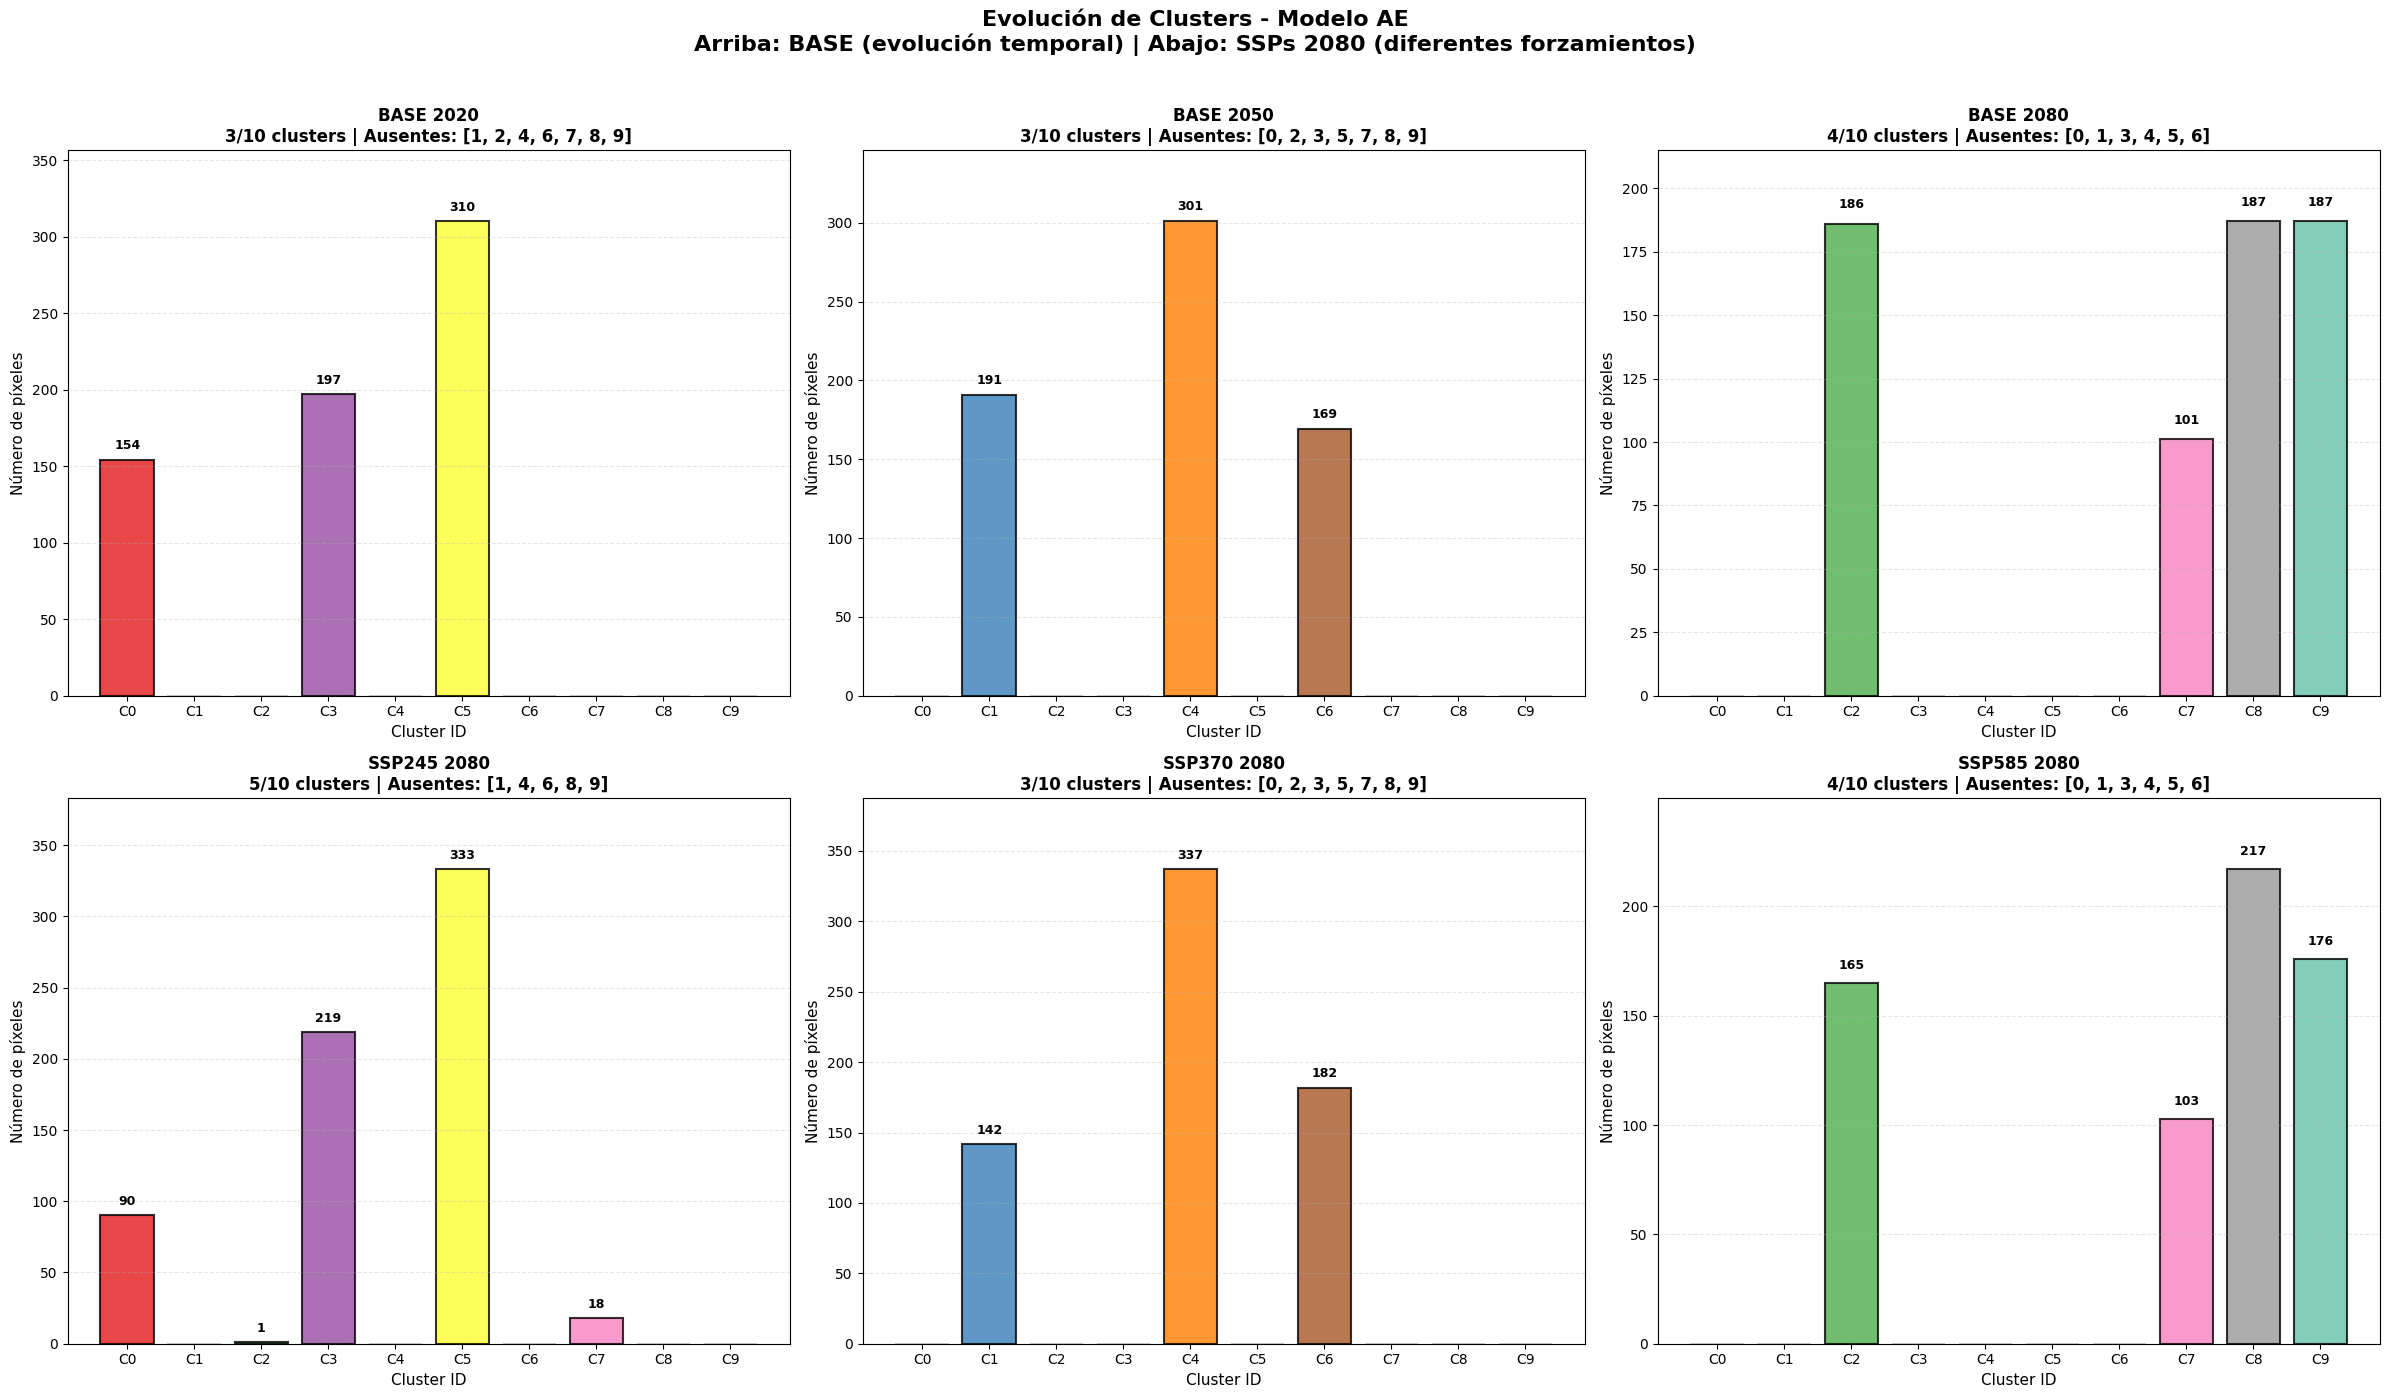


MODELO: VAE

VAE - Clusters por escenario:
  BASE 2020: [np.int32(0), np.int32(1), np.int32(9)]
  BASE 2050: [np.int32(2), np.int32(3), np.int32(6), np.int32(7)]
  BASE 2080: [np.int32(3), np.int32(4), np.int32(5), np.int32(8)]
  SSP245 2080: [np.int32(0), np.int32(1), np.int32(9)]
  SSP370 2080: [np.int32(0), np.int32(2), np.int32(3), np.int32(6), np.int32(7)]
  SSP585 2080: [np.int32(3), np.int32(4), np.int32(5), np.int32(8)]

Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/cluster_evolution_timeline_VAE.png

Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/cluster_evolution_timeline_VAE.png


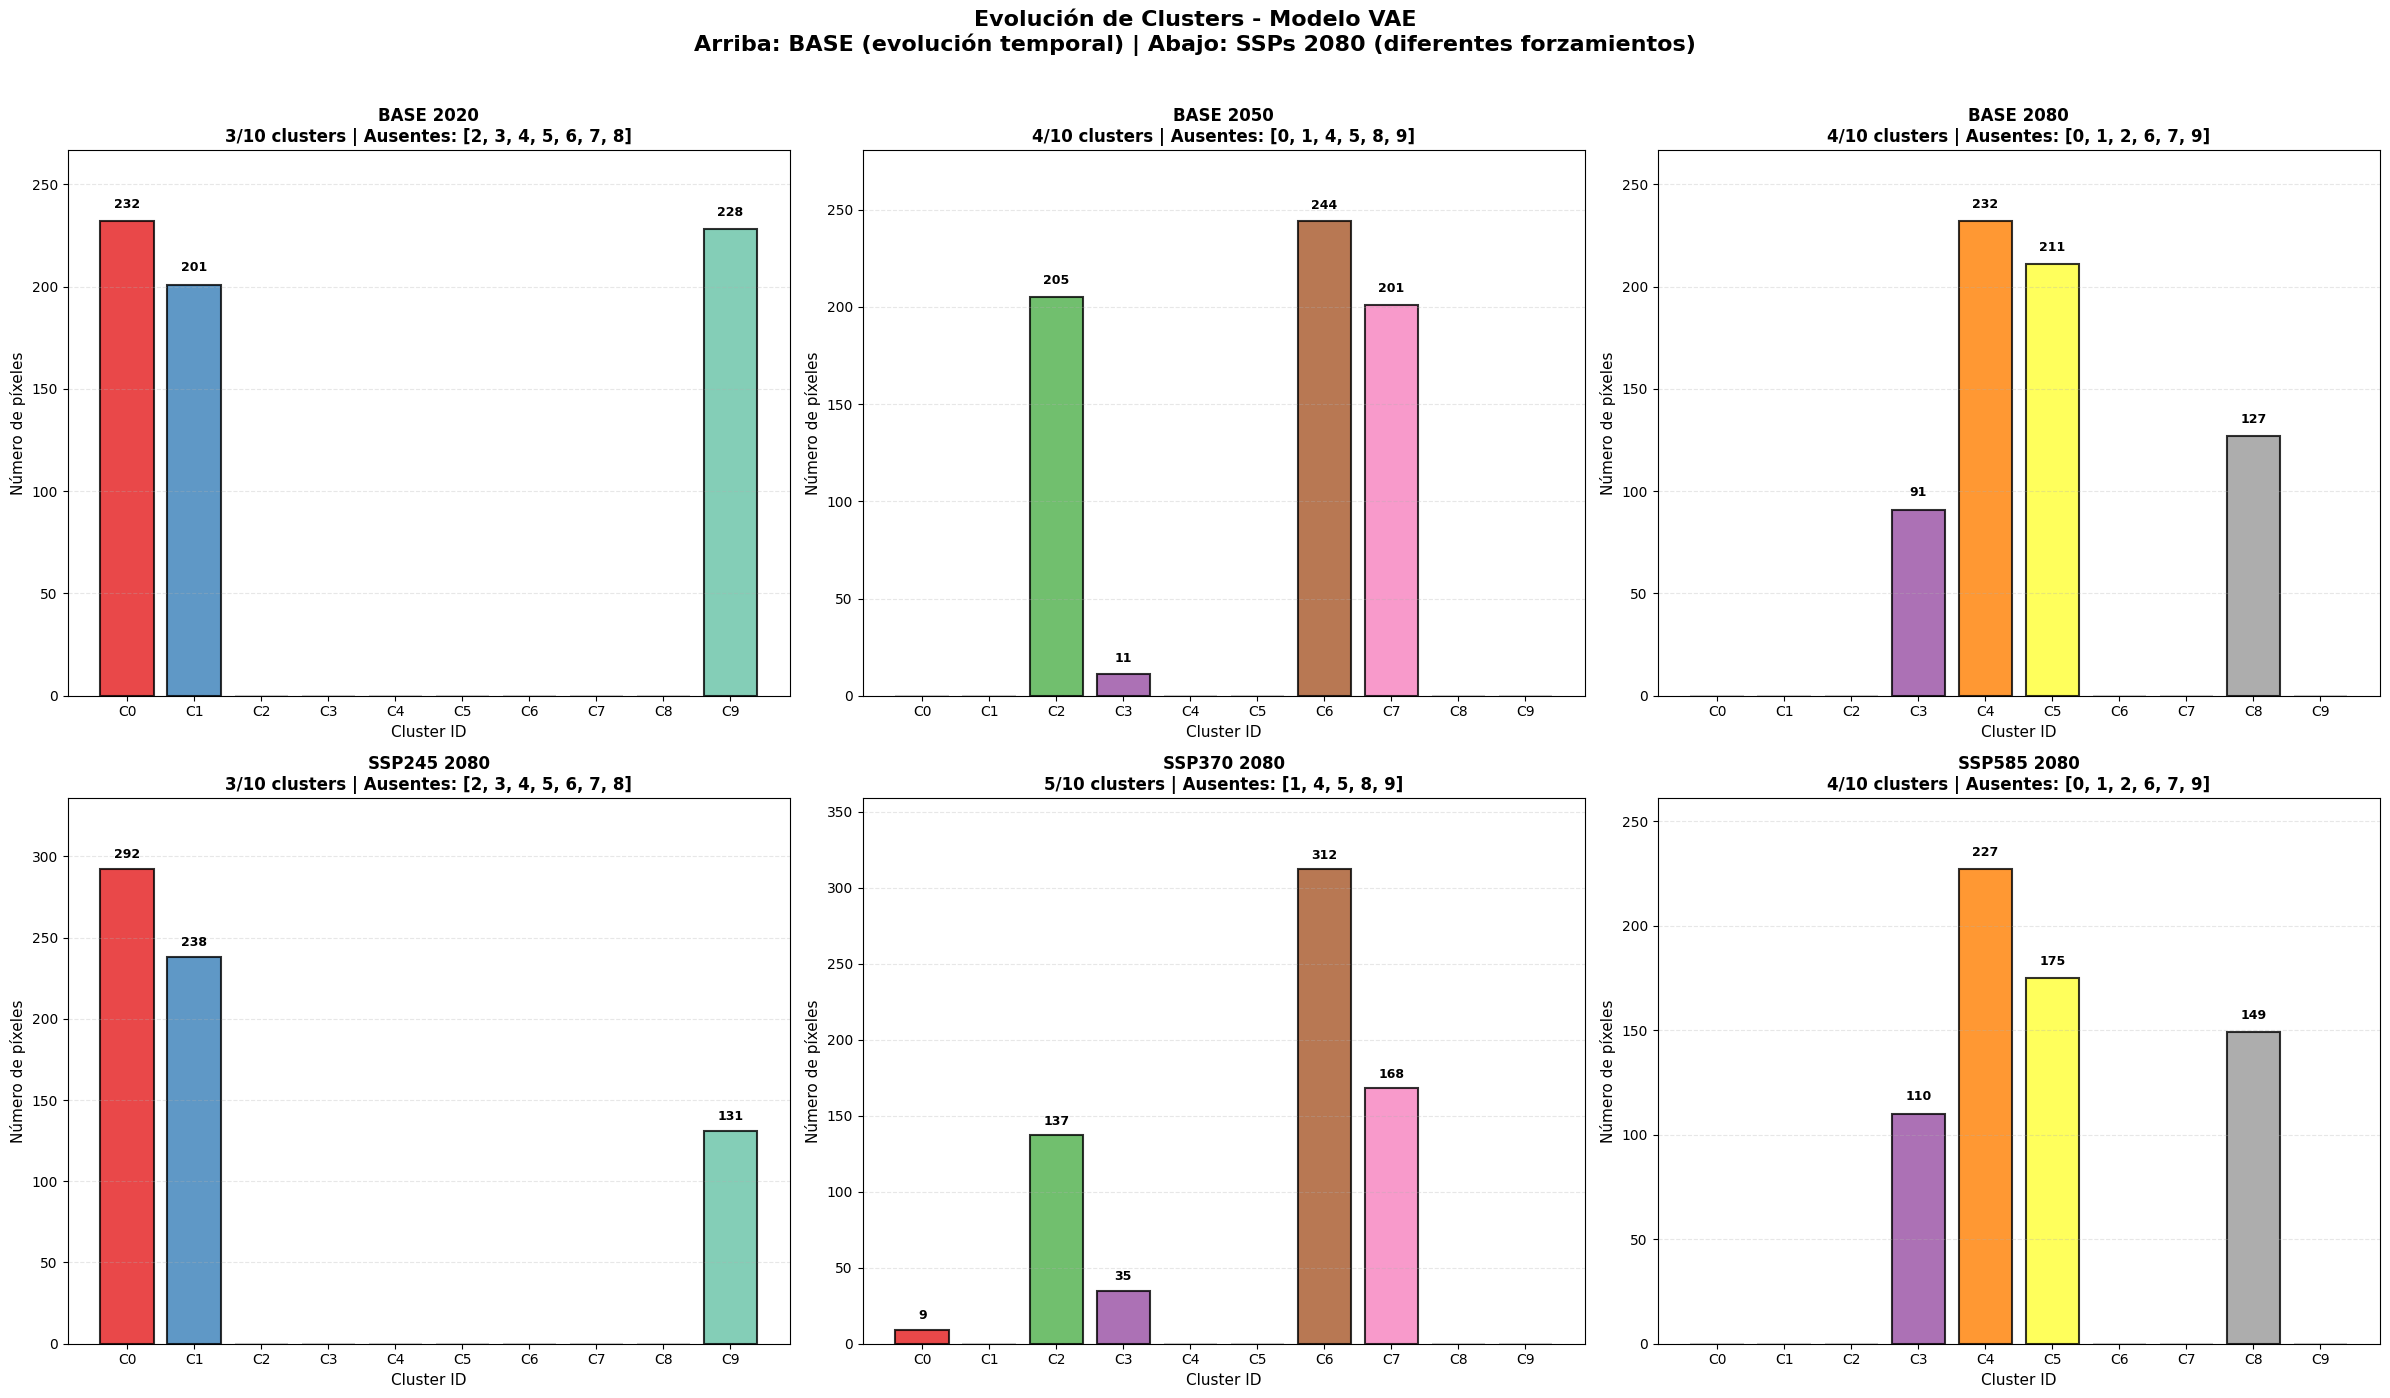

In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def plot_cluster_evolution_timeline(model_key="VAE", figsize=(24, 16)):
    """
    Visualiza evolución temporal y por escenario de clusters.
    Fila 1: BASE 2020, 2050, 2080
    Fila 2: SSP245, SSP370, SSP585 (todos 2080)
    """
    # Recuperar labels
    labels_base_full = LABELS[model_key]["base"]
    labels_245 = LABELS[model_key]["T245"]
    labels_370 = LABELS[model_key]["T370"]
    labels_585 = LABELS[model_key]["T585"]
    
    # BASE: 3 décadas (2020, 2050, 2080)
    n_pix = 661
    labels_base_2020 = labels_base_full[0:n_pix]
    labels_base_2050 = labels_base_full[n_pix:2*n_pix]
    labels_base_2080 = labels_base_full[2*n_pix:]
    
    print(f"\n{model_key} - Clusters por escenario:")
    print(f"  BASE 2020: {sorted(np.unique(labels_base_2020))}")
    print(f"  BASE 2050: {sorted(np.unique(labels_base_2050))}")
    print(f"  BASE 2080: {sorted(np.unique(labels_base_2080))}")
    print(f"  SSP245 2080: {sorted(np.unique(labels_245))}")
    print(f"  SSP370 2080: {sorted(np.unique(labels_370))}")
    print(f"  SSP585 2080: {sorted(np.unique(labels_585))}")
    
    # Colormap
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
              '#ffff33', '#a65628', '#f781bf', '#999999', '#66c2a5']
    cmap = ListedColormap(colors[:K_CLUSTERS])
    
    # Crear grilla 2x3
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # Fila 1: BASE (temporal)
    scenarios_row1 = [
        ("BASE 2020", labels_base_2020),
        ("BASE 2050", labels_base_2050),
        ("BASE 2080", labels_base_2080)
    ]
    
    # Fila 2: SSPs (diferentes forzamientos en 2080)
    scenarios_row2 = [
        ("SSP245 2080", labels_245),
        ("SSP370 2080", labels_370),
        ("SSP585 2080", labels_585)
    ]
    
    all_scenarios = [scenarios_row1, scenarios_row2]
    
    for row_idx, scenarios in enumerate(all_scenarios):
        for col_idx, (title, labels_arr) in enumerate(scenarios):
            ax = axes[row_idx, col_idx]
            
            # Conteo de píxeles por cluster
            counts = np.bincount(labels_arr, minlength=K_CLUSTERS)
            clusters_present = sorted(np.unique(labels_arr))
            clusters_absent = [k for k in range(K_CLUSTERS) if k not in clusters_present]
            
            # Crear barras de frecuencia por cluster
            x = np.arange(K_CLUSTERS)
            bars = ax.bar(x, counts, color=[colors[k] for k in range(K_CLUSTERS)], 
                         edgecolor='black', linewidth=1.5, alpha=0.8)
            
            # Marcar clusters ausentes
            for k in clusters_absent:
                bars[k].set_alpha(0.2)
                bars[k].set_hatch('///')
            
            # Título con info
            n_present = len(clusters_present)
            n_absent = len(clusters_absent)
            ax.set_title(f"{title}\n{n_present}/{K_CLUSTERS} clusters | "
                        f"Ausentes: {clusters_absent if clusters_absent else 'ninguno'}",
                        fontsize=12, fontweight='bold')
            
            ax.set_xlabel('Cluster ID', fontsize=11)
            ax.set_ylabel('Número de píxeles', fontsize=11)
            ax.set_xticks(x)
            ax.set_xticklabels([f'C{k}' for k in range(K_CLUSTERS)])
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, max(counts)*1.15)
            
            # Agregar valores sobre las barras
            for k, count in enumerate(counts):
                if count > 0:
                    ax.text(k, count + 5, f'{int(count)}', 
                           ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.suptitle(f'Evolución de Clusters - Modelo {model_key}\n'
                f'Arriba: BASE (evolución temporal) | Abajo: SSPs 2080 (diferentes forzamientos)',
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    
    # Guardar
    plot_path = os.path.join(PLOTS_DIR, f'cluster_evolution_timeline_{model_key}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nGráfico guardado: {plot_path}")
    
    plt.show()
    return fig


# Ejecutar
print("="*80)
print("GENERANDO VISUALIZACIONES DE EVOLUCIÓN DE CLUSTERS")
print("="*80)

for model_key in MODEL_ORDER:
    print(f"\n{'='*80}")
    print(f"MODELO: {model_key}")
    print(f"{'='*80}")
    fig = plot_cluster_evolution_timeline(model_key=model_key, figsize=(24, 14))

## Mapas Espaciales con Etiquetas Climáticas

Visualización espacial de clusters con etiquetas interpretables para cada modelo y escenario.

In [35]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from sklearn.neighbors import KNeighborsClassifier

def _infer_grid_resolution(n_points):
    """Inferir resolución apropiada del grid de interpolación basado en número de puntos."""
    if n_points < 100:
        return 50
    elif n_points < 500:
        return 80
    elif n_points < 1000:
        return 100
    else:
        return 150

def plot_clusters_spatial_profiling(labels_array, lat_vals, lon_vals, title, 
                                    cluster_labels_dict=None, alpha=0.75, figsize=(10, 10)):
    """
    Plotea clusters en el espacio geográfico con etiquetas interpretables.
    
    Parameters:
    -----------
    labels_array : array-like
        Labels de clusters (puede tener NaN)
    lat_vals : array-like
        Latitudes de los puntos
    lon_vals : array-like
        Longitudes de los puntos
    title : str
        Título del plot
    cluster_labels_dict : dict, optional
        Diccionario {cluster_id: "etiqueta_texto"} para mostrar nombres interpretativos
    alpha : float
        Transparencia del overlay
    figsize : tuple
        Tamaño de la figura
    """
    labels_arr = np.asarray(labels_array)
    
    # CRÍTICO: Truncar labels_arr si es más largo que las coordenadas
    n_coords = len(lat_vals)
    if len(labels_arr) > n_coords:
        print(f"⚠ Truncando labels: {len(labels_arr)} → {n_coords} (tamaño de coordenadas)")
        labels_arr = labels_arr[:n_coords]
    
    valid_mask = ~pd.isna(labels_arr)
    
    if not valid_mask.any():
        print(f"Sin datos válidos para {title}")
        return
    
    unique_vals = np.sort(np.unique(labels_arr[valid_mask]))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Paleta de colores para clusters
    color_palette = plt.get_cmap('tab20', 20)
    cluster_colors = []
    for val in unique_vals:
        color_idx = int(val) % 20
        cluster_colors.append(color_palette(color_idx))
    discrete_cmap = ListedColormap(cluster_colors)
    
    val_to_idx = {val: idx for idx, val in enumerate(unique_vals)}
    
    try:
        # Asegurar que lon/lat tengan el mismo tamaño que labels
        if len(lat_vals) != len(labels_arr) or len(lon_vals) != len(labels_arr):
            print(f"Ajustando dimensiones: labels={len(labels_arr)}, lat={len(lat_vals)}, lon={len(lon_vals)}")
            n_min = min(len(labels_arr), len(lat_vals), len(lon_vals))
            lat_vals = lat_vals[:n_min]
            lon_vals = lon_vals[:n_min]
            labels_arr = labels_arr[:n_min]
            valid_mask = valid_mask[:n_min]
        
        # Proyectar a Web Mercator
        try:
            from pyproj import Transformer
            transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
            xs, ys = transformer.transform(lon_vals, lat_vals)
        except:
            # Fallback: usar lon/lat directamente
            xs = lon_vals * 111320  # Aproximación
            ys = lat_vals * 110540
        
        # Filtrar solo puntos válidos
        xs_valid = xs[valid_mask]
        ys_valid = ys[valid_mask]
        labels_valid = labels_arr[valid_mask]
        
        # Crear grid para interpolación
        grid_res = _infer_grid_resolution(len(xs_valid))
        grid_x = np.linspace(xs.min(), xs.max(), grid_res)
        grid_y = np.linspace(ys.min(), ys.max(), grid_res)
        GX, GY = np.meshgrid(grid_x, grid_y)
        extent_map = (grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max())
        
        # KNN para interpolación
        coords_valid = np.column_stack([xs_valid, ys_valid])
        int_targets = np.vectorize(val_to_idx.get)(labels_valid)
        
        n_neighbors = max(1, min(len(int_targets), int(np.sqrt(len(int_targets)))))
        clf = KNeighborsClassifier(n_neighbors=n_neighbors, weights="distance")
        clf.fit(coords_valid, int_targets)
        
        grid_points = np.column_stack([GX.ravel(), GY.ravel()])
        pred = clf.predict(grid_points).reshape(GX.shape)
        
        # Configurar axes
        ax.set_xlim(extent_map[0], extent_map[1])
        ax.set_ylim(extent_map[2], extent_map[3])
        
        # Agregar basemap (opcional, con manejo robusto de errores)
        try:
            import contextily as ctx
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs="EPSG:3857", 
                          alpha=1.0, attribution_size=6, zoom='auto')
        except Exception as e:
            # No mostrar error, simplemente continuar sin basemap
            pass
        
        # Plotear clusters
        boundaries = np.arange(len(unique_vals) + 1) - 0.5
        norm = BoundaryNorm(boundaries, discrete_cmap.N)
        
        ax.imshow(pred, extent=extent_map, origin="lower", cmap=discrete_cmap, 
                 norm=norm, alpha=alpha, zorder=3)
        ax.set_axis_off()
        ax.set_title(title, fontsize=13, pad=15, fontweight='bold')
        
        # Colorbar simplificado (solo IDs)
        mappable = ScalarMappable(norm=norm, cmap=discrete_cmap)
        cbar = fig.colorbar(mappable, ax=ax, fraction=0.035, pad=0.02, 
                           ticks=np.arange(len(unique_vals)))
        cbar.set_ticklabels([str(int(val)) for val in unique_vals], fontsize=8)
        cbar.set_label("Cluster ID", fontsize=11)
        
        # Agregar etiquetas como anotaciones EN EL MAPA
        if cluster_labels_dict is not None and len(cluster_labels_dict) > 0:
            # Calcular centroide de cada cluster
            for val in unique_vals:
                cluster_id = int(val)
                cluster_mask = labels_valid == val
                
                if cluster_mask.sum() > 0:
                    # Centroide en coordenadas proyectadas
                    centroid_x = xs_valid[cluster_mask].mean()
                    centroid_y = ys_valid[cluster_mask].mean()
                    
                    # Obtener etiqueta
                    label_text = cluster_labels_dict.get(cluster_id, str(cluster_id))
                    
                    # Agregar anotación con fondo semi-transparente
                    ax.annotate(
                        label_text,
                        xy=(centroid_x, centroid_y),
                        fontsize=7,
                        fontweight='bold',
                        color='black',
                        ha='center',
                        va='center',
                        bbox=dict(
                            boxstyle='round,pad=0.4',
                            facecolor='white',
                            edgecolor='gray',
                            alpha=0.85,
                            linewidth=0.8
                        ),
                        zorder=10
                    )
        
        fig.tight_layout()
        plt.show()
        
    except Exception as err:
        print(f"Error en plot_clusters_spatial_profiling: {err}")
        import traceback
        traceback.print_exc()
        plt.close(fig)

print("Funciones de ploteo espacial cargadas correctamente")


Funciones de ploteo espacial cargadas correctamente


In [36]:
def create_cluster_summary_table(labels_numeric, labels_df, scenario_name, 
                                  imp_matrix=None, feature_names=None, k_clusters=None):
    """
    Crea tabla resumen después de visualización espacial.
    
    Parameters:
    -----------
    labels_numeric : np.ndarray
        Array numérico de etiquetas de cluster por píxel
    labels_df : pd.DataFrame
        DataFrame con etiquetas climáticas (de label_table_from_importance)
    scenario_name : str
        Nombre del escenario (BASE, SSP245, etc.)
    imp_matrix : np.ndarray, optional
        Matriz de importancias para análisis de diferenciación
    feature_names : list, optional
        Nombres de variables para análisis
    k_clusters : int, optional
        Número total de clusters (default: max de labels_df)
    
    Returns:
    --------
    pd.DataFrame con resumen por cluster
    """
    if k_clusters is None:
        k_clusters = labels_df['cluster'].max() + 1
    
    # Contar píxeles por cluster
    pixel_counts = np.bincount(labels_numeric, minlength=k_clusters)
    
    # Construir tabla
    summary = []
    for c in range(k_clusters):
        n_pixels = pixel_counts[c]
        pct = (n_pixels / len(labels_numeric)) * 100
        
        # Obtener info del DataFrame de etiquetas
        if c in labels_df['cluster'].values:
            cluster_info = labels_df[labels_df['cluster'] == c].iloc[0]
            label = cluster_info['label']
            drivers = cluster_info['drivers']
            label_full = cluster_info.get('label_complete', label)
            label_disamb = cluster_info.get('label_disambiguated', label)
        else:
            label = "Sin píxeles"
            drivers = ""
            label_full = "N/A"
            label_disamb = "N/A"
        
        summary.append({
            'cluster': c,
            'n_pixels': int(n_pixels),
            'pct': f"{pct:.1f}%",
            'label_clima': label,
            'top_drivers': drivers,
            'label_completa': label_full,
            'label_con_desambiguacion': label_disamb
        })
    
    df_summary = pd.DataFrame(summary)
    
    # Agregar análisis de duplicados si hay importancias
    if imp_matrix is not None and feature_names is not None:
        df_summary['tiene_duplicado'] = df_summary['label_clima'].duplicated(keep=False)
        
        # Para etiquetas duplicadas, agregar métrica de separabilidad
        dup_labels = df_summary[df_summary['tiene_duplicado']]['label_clima'].unique()
        separability = []
        
        for _, row in df_summary.iterrows():
            c = row['cluster']
            if row['label_clima'] in dup_labels:
                # Encontrar otros clusters con misma etiqueta
                same_label_clusters = df_summary[
                    (df_summary['label_clima'] == row['label_clima']) & 
                    (df_summary['cluster'] != c)
                ]['cluster'].tolist()
                
                if same_label_clusters:
                    # Calcular distancia en espacio de importancias
                    other_c = same_label_clusters[0]
                    dist = np.linalg.norm(imp_matrix[c, :] - imp_matrix[other_c, :])
                    separability.append(f"{dist:.2f}")
                else:
                    separability.append("")
            else:
                separability.append("")
        
        df_summary['dist_a_duplicado'] = separability
    
    return df_summary


def print_cluster_summary_after_plot(labels_numeric, labels_df, scenario_name, 
                                      imp_matrix=None, feature_names=None, k_clusters=None):
    """
    Imprime tabla resumen después de un gráfico espacial.
    SOLO muestra clusters que tienen píxeles (los que aparecen en el mapa).
    """
    print()
    print(f"RESUMEN: {scenario_name}")
    print("="*100)
    
    df_summary = create_cluster_summary_table(
        labels_numeric, labels_df, scenario_name, 
        imp_matrix, feature_names, k_clusters
    )
    
    # FILTRAR: Solo clusters con píxeles > 0 (los que realmente aparecen en el mapa)
    df_summary = df_summary[df_summary['n_pixels'] > 0].copy()
    
    # Ordenar por n_pixels descendente
    df_summary = df_summary.sort_values('n_pixels', ascending=False).reset_index(drop=True)
    
    # Mostrar tabla
    display(df_summary)
    
    # Resaltar duplicados si existen (solo entre los clusters visibles)
    if 'tiene_duplicado' in df_summary.columns:
        duplicates = df_summary[df_summary['tiene_duplicado']]
        if len(duplicates) > 0:
            print()
            print(f"⚠ ADVERTENCIA: {len(duplicates)} clusters con etiquetas duplicadas detectados en este mapa")
            print("  Revisar columnas 'label_con_desambiguacion' y 'dist_a_duplicado' para diferencias")
            print()
            # Mostrar solo duplicados
            print("  Clusters con etiquetas duplicadas:")
            display(duplicates[['cluster', 'n_pixels', 'label_clima', 'label_con_desambiguacion', 'dist_a_duplicado']])
    
    print()
    print("="*100)
    print()

print("Funciones de resumen de tablas definidas")
print("  - create_cluster_summary_table()")
print("  - print_cluster_summary_after_plot()")

Funciones de resumen de tablas definidas
  - create_cluster_summary_table()
  - print_cluster_summary_after_plot()


VISUALIZACIÓN ESPACIAL DE CLUSTERS CON ETIQUETAS INTERPRETABLES

Usando coords_df con 661 píxeles válidos
  Coordenadas desde coords_df: 661 puntos
⚠ Ajustando: n_pixels (661) → X_BASE pixels (1983)
  Coordenadas finales: 661 puntos

Visualizando clusters para modelo: AE

Coordenadas preparadas:
  Puntos espaciales: 661
  Labels BASE: 1983
  Labels SSP245: 661
  Labels SSP370: 661
  Labels SSP585: 661

1/4. Baseline (1980-2015)
⚠ Truncando labels: 1983 → 661 (tamaño de coordenadas)


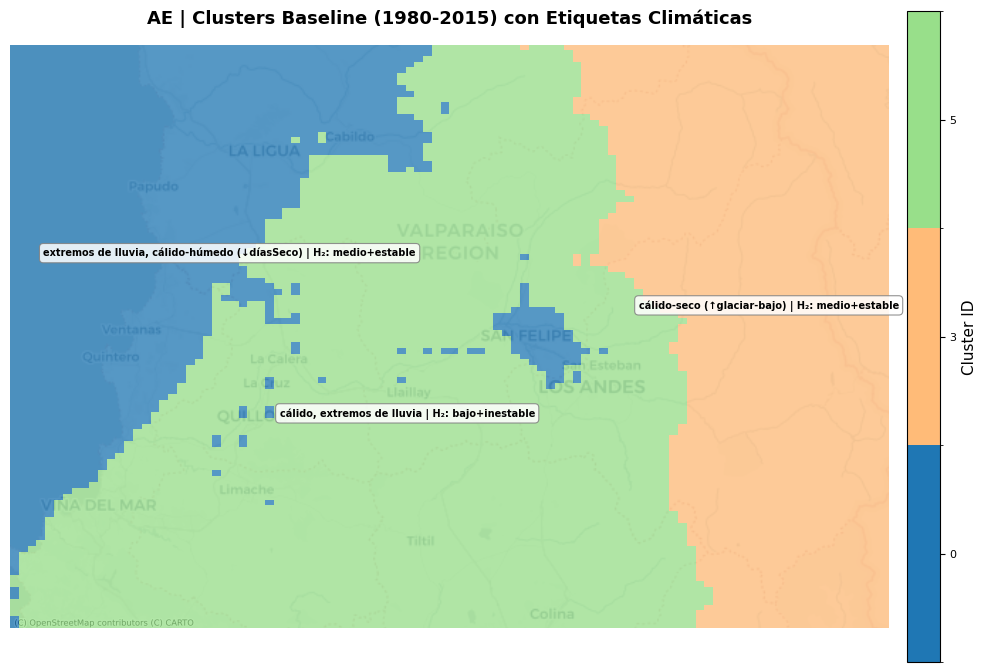

2/4. SSP2-4.5 (2080-2100)


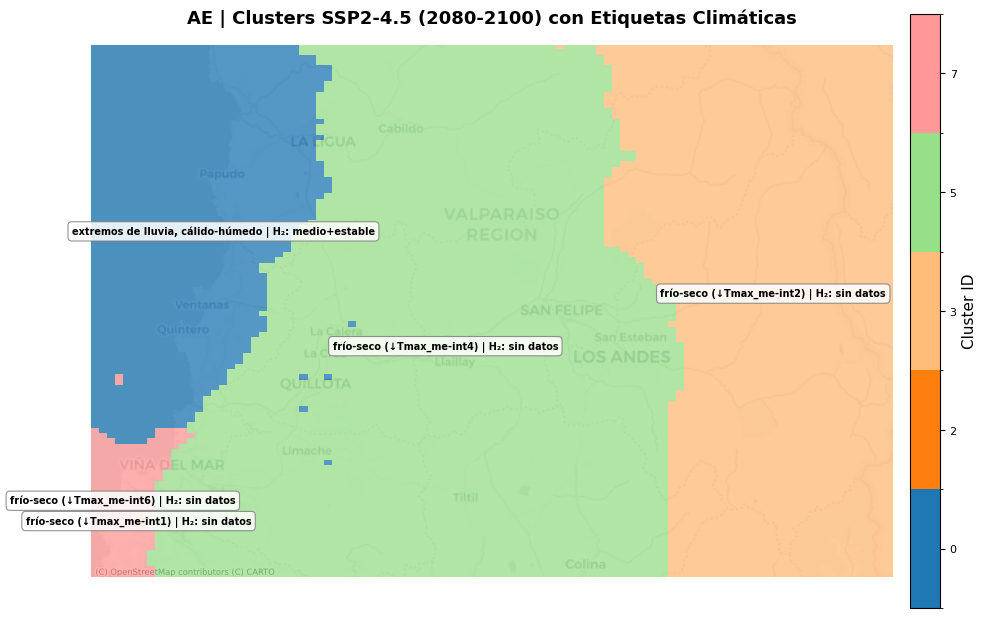

3/4. SSP3-7.0 (2080-2100)


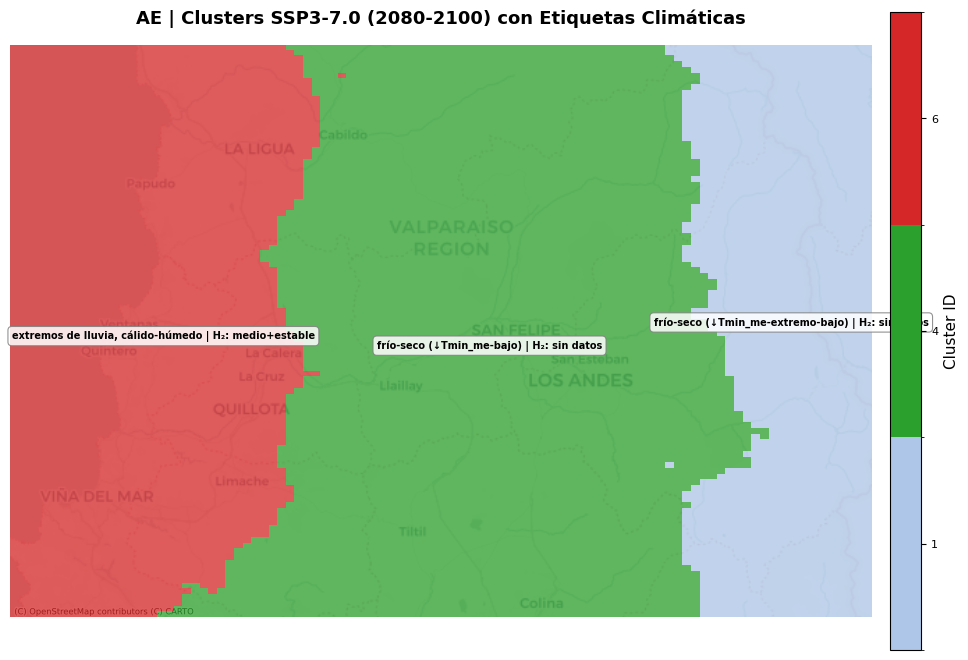

4/4. SSP5-8.5 (2080-2100)


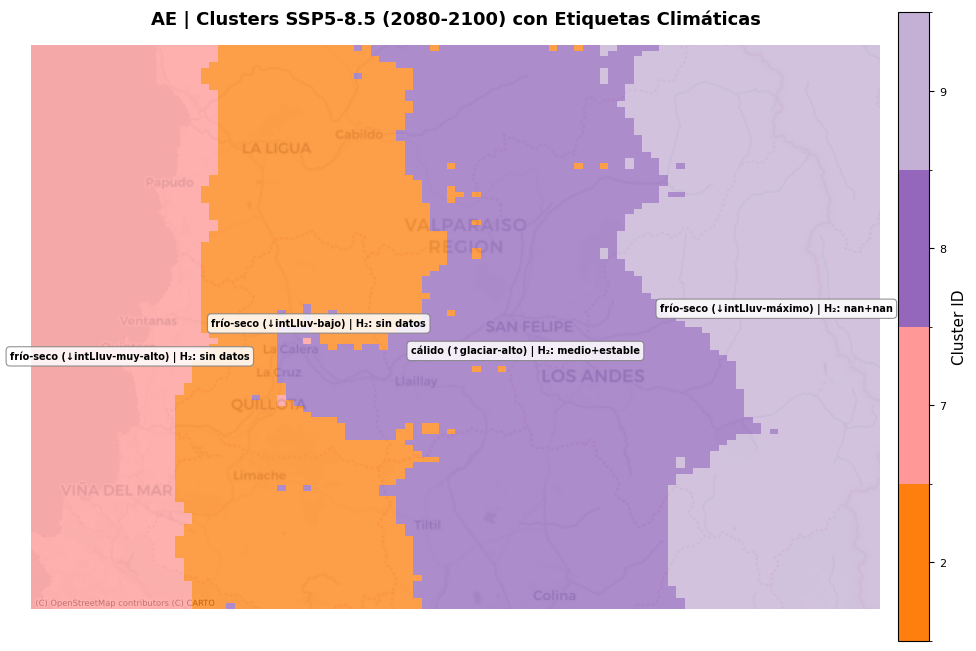


✓ Mapas y tablas resumen generados para AE

Para visualizar el otro modelo (VAE), cambiar model_key = MODEL_ORDER[1] y volver a ejecutar


In [39]:
print("VISUALIZACIÓN ESPACIAL DE CLUSTERS CON ETIQUETAS INTERPRETABLES")
print()

# CRÍTICO: Usar coords_df directamente para obtener coordenadas de píxeles válidos
# coords_df contiene las coordenadas exactas de los píxeles que están en X_BASE
if 'coords_df' in locals() and coords_df is not None:
    print(f"Usando coords_df con {len(coords_df)} píxeles válidos")
    lat_pixels = coords_df['lat'].values
    lon_pixels = coords_df['lon'].values
    print(f"  Coordenadas desde coords_df: {len(lat_pixels)} puntos")
else:
    # Fallback: crear desde meshgrid (menos preciso)
    print("⚠ coords_df no disponible, creando coordenadas desde meshgrid")
    if lat.ndim == 1 and lon.ndim == 1:
        lon_grid_2d, lat_grid_2d = np.meshgrid(lon, lat)
        lat_pixels = lat_grid_2d.flatten()
        lon_pixels = lon_grid_2d.flatten()
        print(f"  Total de píxeles en grid: {len(lat_pixels)}")
        print(f"  Grid: {lat.shape[0]} x {lon.shape[0]} = {lat.shape[0] * lon.shape[0]} puntos")
        print(f"  Píxeles en X_BASE: {X_BASE.shape[0]}")
    else:
        lat_pixels = lat
        lon_pixels = lon

# Verificar que coincida con el número de píxeles en X_BASE
if len(lat_pixels) != X_BASE.shape[0]:
    print(f"⚠ Ajustando: n_pixels ({len(lat_pixels)}) → X_BASE pixels ({X_BASE.shape[0]})")
    lat_pixels = lat_pixels[:X_BASE.shape[0]]
    lon_pixels = lon_pixels[:X_BASE.shape[0]]

print(f"  Coordenadas finales: {len(lat_pixels)} puntos")
print()

# Seleccionar un modelo para visualizar
model_key = MODEL_ORDER[0]  # Cambiar a MODEL_ORDER[1] para VAE
print(f"Visualizando clusters para modelo: {model_key}")
print()

# Obtener las etiquetas climáticas creadas
results = CLUSTERING_RESULTS[model_key]
labels_base_numeric = results['labels_base']
labels_T245_numeric = results['labels_T245']
labels_T370_numeric = results['labels_T370']
labels_T585_numeric = results['labels_T585']

# Preparar coordenadas para baseline
# Si labels_base tiene 3 períodos concatenados, tomar el modo/consenso
if len(labels_base_numeric) == N_PER_SCENARIO * 3:
    from scipy import stats
    labels_base_reshaped = labels_base_numeric.reshape(3, N_PER_SCENARIO)
    labels_base_to_plot = stats.mode(labels_base_reshaped, axis=0, nan_policy='omit', keepdims=False).mode
else:
    labels_base_to_plot = labels_base_numeric[:N_PER_SCENARIO]

# Usar las mismas coordenadas para todos los escenarios (son los mismos píxeles espaciales)
lat_base = lat_pixels
lon_base = lon_pixels
lat_target = lat_pixels
lon_target = lon_pixels

print(f"Coordenadas preparadas:")
print(f"  Puntos espaciales: {len(lat_pixels)}")
print(f"  Labels BASE: {len(labels_base_to_plot)}")
print(f"  Labels SSP245: {len(labels_T245_numeric)}")
print(f"  Labels SSP370: {len(labels_T370_numeric)}")
print(f"  Labels SSP585: {len(labels_T585_numeric)}")
print()

# Crear diccionarios de etiquetas si labels_BASE_clim existe
cluster_labels_base = {}
cluster_labels_T245 = {}
cluster_labels_T370 = {}
cluster_labels_T585 = {}

# Extraer etiquetas desde los DataFrames creados en celdas anteriores
# CRÍTICO: Usar label_complete (incluye clima + drivers + H₂) para etiquetas enriquecidas
# NOTA: Algunos clusters pueden no tener píxeles, agregar etiqueta de fallback

def extract_cluster_labels(labels_df, k_clusters):
    """
    Extrae etiquetas de un DataFrame y agrega fallback para clusters sin píxeles.
    
    Parameters:
    -----------
    labels_df : pd.DataFrame
        DataFrame con etiquetas por cluster
    k_clusters : int
        Número total de clusters esperados (0 a k_clusters-1)
    
    Returns:
    --------
    dict : {cluster_id: label_text}
    """
    cluster_labels = {}
    
    # Obtener clusters existentes en el DataFrame
    existing_clusters = set(labels_df['cluster'].unique())
    
    # Para cada cluster esperado
    for cluster_id in range(k_clusters):
        if cluster_id in existing_clusters:
            # Cluster existe, extraer etiqueta
            cluster_data = labels_df[labels_df['cluster'] == cluster_id]
            if 'label_complete' in cluster_data.columns:
                cluster_labels[cluster_id] = cluster_data['label_complete'].iloc[0]
            elif 'label_compact' in cluster_data.columns:
                cluster_labels[cluster_id] = cluster_data['label_compact'].iloc[0]
            elif 'label' in cluster_data.columns:
                cluster_labels[cluster_id] = cluster_data['label'].iloc[0]
            else:
                cluster_labels[cluster_id] = f"Cluster {cluster_id} (sin etiqueta)"
        else:
            # Cluster no existe en los datos, agregar etiqueta placeholder
            cluster_labels[cluster_id] = f"Sin píxeles (cluster vacío)"
    
    return cluster_labels

if 'labels_BASE' in locals() and labels_BASE is not None:
    cluster_labels_base = extract_cluster_labels(labels_BASE, K_CLUSTERS)

if 'labels_T245' in locals() and labels_T245 is not None:
    cluster_labels_T245 = extract_cluster_labels(labels_T245, K_CLUSTERS)

if 'labels_T370' in locals() and labels_T370 is not None:
    cluster_labels_T370 = extract_cluster_labels(labels_T370, K_CLUSTERS)

if 'labels_T585' in locals() and labels_T585 is not None:
    cluster_labels_T585 = extract_cluster_labels(labels_T585, K_CLUSTERS)

print("1/4. Baseline (1980-2015)")
plot_clusters_spatial_profiling(
    labels_array=labels_base_to_plot,
    lat_vals=lat_base,
    lon_vals=lon_base,
    title=f"{model_key} | Clusters Baseline (1980-2015) con Etiquetas Climáticas",
    cluster_labels_dict=cluster_labels_base if cluster_labels_base else None,
    alpha=0.75,
    figsize=(10, 10)
)

print("2/4. SSP2-4.5 (2080-2100)")
plot_clusters_spatial_profiling(
    labels_array=labels_T245_numeric,
    lat_vals=lat_target,
    lon_vals=lon_target,
    title=f"{model_key} | Clusters SSP2-4.5 (2080-2100) con Etiquetas Climáticas",
    cluster_labels_dict=cluster_labels_T245 if cluster_labels_T245 else None,
    alpha=0.75,
    figsize=(10, 10)
)

print("3/4. SSP3-7.0 (2080-2100)")
plot_clusters_spatial_profiling(
    labels_array=labels_T370_numeric,
    lat_vals=lat_target,
    lon_vals=lon_target,
    title=f"{model_key} | Clusters SSP3-7.0 (2080-2100) con Etiquetas Climáticas",
    cluster_labels_dict=cluster_labels_T370 if cluster_labels_T370 else None,
    alpha=0.75,
    figsize=(10, 10)
)

print("4/4. SSP5-8.5 (2080-2100)")
plot_clusters_spatial_profiling(
    labels_array=labels_T585_numeric,
    lat_vals=lat_target,
    lon_vals=lon_target,
    title=f"{model_key} | Clusters SSP5-8.5 (2080-2100) con Etiquetas Climáticas",
    cluster_labels_dict=cluster_labels_T585 if cluster_labels_T585 else None,
    alpha=0.75,
    figsize=(10, 10)
)

print()
print(f"✓ Mapas y tablas resumen generados para {model_key}")
print()
print("Para visualizar el otro modelo (VAE), cambiar model_key = MODEL_ORDER[1] y volver a ejecutar")
